In [ ]:
# -*- coding: utf-8 -*-
"""yunda

Automatically generated by Colab.
Modified for Local and Colab compatibility with bulletproof dynamic paths.
"""

# ==============================================================================
# Environment Setup (Fleksibel: Lokal / Colab)
# ==============================================================================
import os
import sys
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV, LeaveOneGroupOut
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

# Deteksi otomatis lingkungan eksekusi
IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive', force_remount=True)
    print("Berjalan di Google Colab. Drive berhasil di-mount.")
else:
    print("Berjalan di Environment Lokal (PC). Melewati proses mount Google Drive.")

# Supaya fungsi display() bawaan notebook tidak error di terminal lokal
if not IS_COLAB:
    def display(df_to_show):
        print(df_to_show)

# ==============================================================================
# Konfigurasi Folder (Dinamis: Otomatis Mendeteksi Folder Pelabelan)
# ==============================================================================
if IS_COLAB:
    BASE_DIR = "/content/drive/MyDrive/Skripsi"
    OUTPUT_DIR = os.path.join(BASE_DIR, "pelabelan")
else:
    # Mengambil path folder tempat file train.py ini berada (D:\SKRIPSI\code-deteksi\silat)
    CURRENT_SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
    # Menggabungkan dengan folder 'pelabelan' yang ada di dalamnya
    OUTPUT_DIR = os.path.join(CURRENT_SCRIPT_DIR, "pelabelan")

DATA_FILE = os.path.join(OUTPUT_DIR, "dataset_berlabel.csv")
MODEL_DIR = os.path.join(OUTPUT_DIR, "model")
CHART_DIR = os.path.join(OUTPUT_DIR, "evaluasi_charts")

# Membuat folder model dan evaluasi jika belum ada
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHART_DIR, exist_ok=True)

MOVEMENT_CLASSES = [
    "Jep Kiri", "Jep Kanan",
    "Tangkisan Kiri", "Tangkisan Kanan",
    "Kombinasi Kiri", "Kombinasi Kanan",
]

# ==============================================================================
# Load Data
# ==============================================================================
print(f"Memuat dataset dari: {DATA_FILE}")
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(f"File {DATA_FILE} tidak ditemukan. Pastikan file 'dataset_berlabel.csv' berada di folder silat\\pelabelan.")

df = pd.read_csv(DATA_FILE)
df.columns = df.columns.str.strip()
print("Dataset Shape:", df.shape)
print("Jumlah unik segment_id:", df['segment_id'].nunique())

# ==============================================================================
# Exploratory Data Analysis (EDA) - Distribusi Movement
# ==============================================================================
print("=" * 70)
print("ANALISIS TARGET : MOVEMENT")
print("=" * 70)

counts_mv = df['movement'].value_counts()
distribusi_mv = counts_mv.reset_index()
distribusi_mv.columns = ['Kelas Gerakan', 'Jumlah Sampel']
print("\nDistribusi Data Gerakan:")
display(distribusi_mv)

plt.figure(figsize=(8, 4))
sns.countplot(data=df, y='movement', order=counts_mv.index, color='#FF007F')
plt.title('Distribusi Kelas Target Movement')
plt.xlabel('Jumlah Sampel')
plt.ylabel('Kelas Gerakan')
for i, v in enumerate(counts_mv.values):
    plt.text(v + 1, i, str(v), va='center')
plt.tight_layout()
plt.show()

imbalance_ratio_mv = counts_mv.min() / counts_mv.max()
print(f"Rasio Minoritas / Mayoritas Gerakan: {imbalance_ratio_mv:.3f}")

# ==============================================================================
# Deskriptif Awal & Data Cleaning
# ==============================================================================
print("\n=== ANALISIS DESKRIPTIF AWAL DATASET ===")
print(f"Jumlah Baris : {df.shape[0]}")
print(f"Jumlah Kolom : {df.shape[1]}")

MAP_GERAKAN = {
    'Jep Kiri': 0, 'Jep Kanan': 1,
    'Tangkisan Kiri': 2, 'Tangkisan Kanan': 3,
    'Kombinasi Kiri': 4, 'Kombinasi Kanan': 5
}
MAP_KUALITAS = {'Benar': 1, 'Salah': 0}

if df['movement'].dtype == 'object':
    print("\nMapping movement dari string ke integer...")
    df['movement'] = df['movement'].map(MAP_GERAKAN)
else:
    print("\nMovement sudah numerik, mapping tidak diperlukan.")

if df['correctness'].dtype == 'object':
    print("Mapping correctness dari string ke integer...")
    df['correctness'] = df['correctness'].map(MAP_KUALITAS)
else:
    print("Correctness sudah numerik, mapping tidak diperlukan.")

df = df.dropna(subset=['movement', 'correctness'])
df['movement'] = df['movement'].astype(int)
df['correctness'] = df['correctness'].astype(int)

print(f"\nJumlah baris setelah cleaning target: {len(df)}")
print("\n=== Distribusi Gerakan (encoded) ===")
display(df['movement'].value_counts().sort_index().to_frame('Jumlah Sampel'))

print("\n=== Distribusi Kualitas Gerakan (encoded) ===")
display(df['correctness'].value_counts().to_frame('Jumlah Sampel'))

sensor_cols = [c for c in df.columns if c not in ['subject_id', 'timestamp', 'segment_id', 'movement', 'correctness']]
print("\n=== Statistik Deskriptif Sensor ===")
display(df[sensor_cols].describe())

# ==============================================================================
# Distribusi Correctness
# ==============================================================================
print("=" * 70)
print("ANALISIS TARGET : CORRECTNESS")
print("=" * 70)

counts_corr = df['correctness'].value_counts()
distribusi_corr = counts_corr.reset_index()
distribusi_corr.columns = ['Kualitas Kinerja', 'Jumlah Sampel']
print("\nDistribusi Data Kualitas Gerakan (0=Salah, 1=Benar):")
display(distribusi_corr)

plt.figure(figsize=(6, 3))
sns.countplot(data=df, x='correctness', order=counts_corr.index, color='#FF007F')
plt.title('Distribusi Kelas Target Correctness')
plt.ylabel('Jumlah Sampel')
plt.xlabel('Kualitas Kinerja (0=Salah, 1=Benar)')
for i, v in enumerate(counts_corr.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.tight_layout()
plt.show()

imbalance_ratio_corr = counts_corr.min() / counts_corr.max()
print(f"Rasio Minoritas / Mayoritas Correctness: {imbalance_ratio_corr:.3f}")

# ==============================================================================
# Plot Waveform
# ==============================================================================
print("=== VISUALISASI WAVEFORM UNTUK SEMUA SENSOR IMU (0-3) ===")
sumbu_list = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

for sid in range(4):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
    axes = axes.flatten()

    for idx, s in enumerate(sumbu_list):
        col = f'{s}{sid}'
        if col in df.columns:
            axes[idx].plot(df[col].values[:300], color='#FF007F', alpha=0.8, lw=1.2)
            axes[idx].set_title(f"Waveform {col.upper()}", fontsize=11, weight='bold')
            axes[idx].set_ylabel("Amplitudo")
            axes[idx].grid(alpha=0.3)

    plt.suptitle(f"Isyarat Sinyal Mentah - Sensor IMU {sid}", fontsize=14, weight='bold')
    plt.xlabel("Indeks Sampel")
    plt.tight_layout()
    plt.show()

# ==============================================================================
# Plot Boxplot Global
# ==============================================================================
print("=== VISUALISASI BOXPLOT UNTUK SEMUA SENSOR (24 KOLOM) ===")
plt.figure(figsize=(20, 6))
df[sensor_cols].boxplot(rot=45, patch_artist=True,
                        boxprops=dict(facecolor='#FFB6C1', color='#FF007F'),
                        whiskerprops=dict(color='#FF007F'),
                        medianprops=dict(color='black', linewidth=1.5))
plt.title("Boxplot Rentang Nilai Seluruh Sensor (24 Kolom)", fontsize=14, weight='bold')
plt.ylabel("Amplitudo / Nilai Sensor")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================================================================
# Stats per Movement
# ==============================================================================
mapping_nama_gerakan = {0: 'Jep Kiri', 1: 'Jep Kanan', 2: 'Tangkisan Kiri', 3: 'Tangkisan Kanan', 4: 'Kombinasi Kiri', 5: 'Kombinasi Kanan'}

def hitung_5_statistik_sinyal(x):
    if len(x) == 0: return [np.nan] * 5
    return [np.mean(x), np.std(x), np.min(x), np.max(x), np.sqrt(np.mean(x**2))]

stat_names = ['Mean', 'Std', 'Min', 'Max', 'RMS']

print("=== STATISTIK DESKRIPTIF 5 FITUR UTAMA BERDASARKAN KODE GERAKAN ===")
for kode in sorted(df['movement'].unique()):
    nama_g = mapping_nama_gerakan.get(kode, f"Kode {kode}")
    print(f"\n>>> MATRIKS STATISTIK SENSOR KOMPLIT - GERAKAN: {nama_g.upper()}")
    sub_data = df[df['movement'] == kode]
    matriks_stats_g = [hitung_5_statistik_sinyal(sub_data[col].values) for col in sensor_cols]
    display(pd.DataFrame(matriks_stats_g, index=sensor_cols, columns=stat_names).round(3))

# ==============================================================================
# Stats per Correctness
# ==============================================================================
mapping_kualitas = {1: "Benar", 0: "Salah"}

print("=== STATISTIK DESKRIPTIF 5 FITUR UTAMA BERDASARKAN KUALITAS GERAKAN ===")
for kode in sorted(df['correctness'].unique()):
    nama_k = mapping_kualitas.get(kode, f"Kode {kode}")
    print(f"\n>>> MATRIKS STATISTIK SENSOR KOMPLIT - KUALITAS: {nama_k.upper()}")
    sub_data = df[df['correctness'] == kode]
    matriks_stats_k = [hitung_5_statistik_sinyal(sub_data[col].values) for col in sensor_cols]
    display(pd.DataFrame(matriks_stats_k, index=sensor_cols, columns=stat_names).round(3))

# ==============================================================================
# Plot Komparasi Sumbu
# ==============================================================================
def plot_sinyal_komplit_per_sumbu(dataframe, tipe_sumbu, target_col='movement', max_samples=500):
    cols_terpilih = [c for c in sensor_cols if c.startswith(tipe_sumbu)]
    if not cols_terpilih: return
    target_vals = sorted(dataframe[target_col].unique())
    n_subplots = len(target_vals)
    fig, axes = plt.subplots(n_subplots, 1, figsize=(14, 2.5 * n_subplots), sharex=True)
    if n_subplots == 1: axes = [axes]
    for i, val in enumerate(target_vals):
        subset = dataframe[dataframe[target_col] == val].iloc[:max_samples]
        for col in cols_terpilih:
            axes[i].plot(subset[col].values, label=col.upper(), alpha=0.7, lw=1.0)
        label_title = mapping_nama_gerakan.get(val, val) if target_col == 'movement' else mapping_kualitas.get(val, val)
        axes[i].set_title(f'{target_col.upper()} = {val} ({label_title}) - Kelompok Sumbu {tipe_sumbu.upper()}', fontsize=10)
        axes[i].legend(loc='upper right', fontsize=7, ncol=4)
        axes[i].grid(alpha=0.3)
    plt.xlabel("Indeks Sampel"); plt.tight_layout(); plt.show()

print("=== GRAFIK KOMPARASI ISYARAT SUMBU (SENSOR 0-3) BERDASARKAN GERAKAN ===")
for komponen in ['ax', 'ay', 'az', 'gx', 'gy', 'gz']:
    plot_sinyal_komplit_per_sumbu(df, komponen, target_col='movement', max_samples=500)

# ==============================================================================
# Plot Boxplot Kelompok
# ==============================================================================
def plot_boxplot_sensor_global(dataframe, target_col):
    target_vals = sorted(dataframe[target_col].unique())
    n_subplots = len(target_vals)
    fig, axes = plt.subplots(n_subplots, 1, figsize=(16, 5 * n_subplots))
    if n_subplots == 1: axes = [axes]
    for i, val in enumerate(target_vals):
        subset = dataframe[dataframe[target_col] == val]
        subset[sensor_cols].boxplot(ax=axes[i], rot=45, patch_artist=True, boxprops=dict(facecolor='#FFB6C1', color='#FF007F'))
        label_title = mapping_nama_gerakan.get(val, val) if target_col == 'movement' else mapping_kualitas.get(val, val)
        axes[i].set_title(f'Karakteristik Distribusi Nilai Sensor Global [ {target_col.upper()} = {val} ({label_title}) ]', fontsize=12, weight='bold')
        axes[i].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

print("=== BOXPLOT DISTRIBUSI SEBARAN GLOBAL KESELURUHAN SENSOR ===")
print("\n[Berdasarkan Kategori Gerakan]")
plot_boxplot_sensor_global(df, target_col='movement')

print("\n[Berdasarkan Kategori Kualitas/Correctness]")
plot_boxplot_sensor_global(df, target_col='correctness')

# ==============================================================================
# Cleaning Data Tambahan & Validasi
# ==============================================================================
print("=== PENGECEKAN DATA KOSONG (MISSING VALUES) ===")
missing_data = df.isnull().sum()
missing_cols = missing_data[missing_data > 0]
if len(missing_cols) > 0:
    print("Ditemukan kolom dengan nilai kosong, mengeksekusi interpolasi...")
    df[sensor_cols] = df[sensor_cols].interpolate(method='linear', limit_direction='both')
else:
    print("Aman! Tidak ada nilai kosong pada kolom dataset.")

if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("- Baris duplikat berhasil dihapus.")

print("=== VALIDASI AKHIR DATA CLEANING ===")
print(f"Total Nilai Kosong Tersisa : {df.isnull().sum().sum()}")
print(f"Total Baris Duplikat Tersisa: {df.duplicated().sum()}")

# ==============================================================================
# Preprocessing - Ekstraksi Fitur
# ==============================================================================
N_SENSORS = 4
ACCEL_COLS = [[f"a{a}{i}" for a in "xyz"] for i in range(N_SENSORS)]
GYRO_COLS  = [[f"g{a}{i}" for a in "xyz"] for i in range(N_SENSORS)]

def _channel_stats(x):
    if len(x) == 0: return [0.0]*5
    mean = np.mean(x)
    std = np.std(x)
    xmin = np.min(x)
    xmax = np.max(x)
    rms = np.sqrt(np.mean(x**2))
    return [mean, std, xmin, xmax, rms]

def _safe_corr(a, b):
    if len(a) < 3 or np.std(a) < 1e-9 or np.std(b) < 1e-9: return 0.0
    return np.corrcoef(a, b)[0, 1]

def _accel_mag(data, cols, si):
    idx = [cols.index(c) for c in ACCEL_COLS[si] if c in cols]
    if not idx: return np.zeros(len(data))
    return np.sqrt(np.sum(data[:, idx]**2, axis=1))

def _gyro_mag(data, cols, si):
    idx = [cols.index(c) for c in GYRO_COLS[si] if c in cols]
    if not idx: return np.zeros(len(data))
    return np.sqrt(np.sum(data[:, idx]**2, axis=1))

def extract_features_from_segment(segment):
    data = segment.values.astype(float)
    cols = segment.columns.tolist()
    n = len(data); EPS = 1e-9; f = []

    for i in range(data.shape[1]):
        f.extend(_channel_stats(data[:, i]))

    s0a = _accel_mag(data, cols, 0); s1a = _accel_mag(data, cols, 1)
    s2a = _accel_mag(data, cols, 2); s3a = _accel_mag(data, cols, 3)
    s0g = _gyro_mag(data, cols, 0); s1g = _gyro_mag(data, cols, 1)
    s2g = _gyro_mag(data, cols, 2); s3g = _gyro_mag(data, cols, 3)

    for am, gm in [(s0a, s0g), (s1a, s1g), (s2a, s2g), (s3a, s3g)]:
        f.extend(_channel_stats(am)); f.extend(_channel_stats(gm))

    ra = (s0a + s1a) / 2; la = (s2a + s3a) / 2
    rg = (s0g + s1g) / 2; lg = (s2g + s3g) / 2

    f.extend(_channel_stats(ra - la)); f.extend(_channel_stats(rg - lg))

    f.append(np.mean(s0a) / (np.mean(s0a) + np.mean(s1a) + EPS))
    f.append(np.mean(s3a) / (np.mean(s3a) + np.mean(s2a) + EPS))
    f.append(np.mean(s0g) / (np.mean(s0g) + np.mean(s1g) + EPS))
    f.append(np.mean(s3g) / (np.mean(s3g) + np.mean(s2g) + EPS))
    f.append(_safe_corr(s0a, s1a)); f.append(_safe_corr(s3a, s2a))
    f.append(_safe_corr(s0g, s1g)); f.append(_safe_corr(s3g, s2g))
    f.append(float(np.max(ra)) / (float(np.max(la)) + EPS))
    f.append(float(np.max(rg)) / (float(np.max(lg)) + EPS))
    f.append(float(np.argmax(s0a)) / max(n - 1, 1))
    f.append(float(np.argmax(s1a)) / max(n - 1, 1))
    f.append(float(np.argmax(s3a)) / max(n - 1, 1))
    f.append(float(np.argmax(s2a)) / max(n - 1, 1))
    f.append(float(np.mean(ra**2))); f.append(float(np.mean(la**2)))
    f.append(float(np.mean(rg**2))); f.append(float(np.mean(lg**2)))

    return np.array(f, dtype=np.float64)

# ==============================================================================
# Build Dataset
# ==============================================================================
def build_dataset_from_segments():
    sensor_cols = [c for c in df.columns if c not in ['subject_id', 'timestamp', 'segment_id', 'movement', 'correctness']]
    X_list, y_mv_list, y_corr_list, subj_list = [], [], [], []
    per_class = {mv: {"X": [], "y": [], "subjects": []} for mv in MOVEMENT_CLASSES}

    for seg_id in df['segment_id'].unique():
        seg = df[df['segment_id'] == seg_id]
        if len(seg) < 2: continue

        mv_val = seg['movement'].iloc[0]

        if isinstance(mv_val, (int, np.integer)):
            mv_int = int(mv_val)
            if mv_int < len(MOVEMENT_CLASSES):
                mv_str = MOVEMENT_CLASSES[mv_int]
            else:
                continue
        else:
            mv_str = str(mv_val).strip()
            if mv_str in MOVEMENT_CLASSES:
                mv_int = MOVEMENT_CLASSES.index(mv_str)
            else:
                continue

        corr = int(seg['correctness'].iloc[0])
        subj_id = int(seg['subject_id'].iloc[0])

        seg_sensor = seg[sensor_cols]
        feat = extract_features_from_segment(seg_sensor)

        X_list.append(feat)
        y_mv_list.append(mv_int)
        y_corr_list.append(corr)
        subj_list.append(subj_id)

        per_class[mv_str]["X"].append(feat)
        per_class[mv_str]["y"].append(corr)
        per_class[mv_str]["subjects"].append(subj_id)

    X_mv = np.array(X_list)
    y_mv_int = np.array(y_mv_list)
    y_corr_arr = np.array(y_corr_list)
    subjects_arr = np.array(subj_list)

    for mv in MOVEMENT_CLASSES:
        per_class[mv]["X"] = np.array(per_class[mv]["X"])
        per_class[mv]["y"] = np.array(per_class[mv]["y"])
        per_class[mv]["subjects"] = np.array(per_class[mv]["subjects"])

    print(f"Loaded {len(X_mv)} segments")
    print(f"Dimensi Fitur Saat Ini: {X_mv.shape[1]} (Menggunakan 5 Fitur Utama)")
    return X_mv, y_mv_int, y_corr_arr, subjects_arr, per_class

X_mv, y_mv_int, y_corr, subjects, per_class = build_dataset_from_segments()

# ==============================================================================
# Pipeline & Tuning Setup
# ==============================================================================
def build_smote_pipeline(params):
    p = params.copy()
    k = p.pop('select__k')
    smote_k = p.pop('smote__k_neighbors', 5)
    svm_params = {key[5:]: val for key, val in p.items() if key.startswith('svm__')}
    svc = SVC(**svm_params)
    return ImbPipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('scaler', StandardScaler()),
        ('select', SelectKBest(f_classif, k=k)),
        ('smote', SMOTE(random_state=42, k_neighbors=smote_k)),
        ('svm', svc)
    ])

def tune_movement_smote(X, y, groups):
    print("\nTuning Movement Classifier...")
    base = {
        'svm__degree': 2, 'svm__coef0': 0.5, 'svm__shrinking': False, 'svm__tol': 0.001,
        'svm__probability': True, 'svm__random_state': 42, 'svm__decision_function_shape': 'ovo'
    }
    counts = np.bincount(y)
    min_samples = np.min(counts[counts > 0])
    k_max = min(5, min_samples - 1) if min_samples > 1 else 2
    grid = {
        'select__k': [20, 50, 100, 150],
        'svm__C': [0.01, 0.1, 1, 10],
        'svm__gamma': ['scale', 0.01, 0.1],
        'svm__kernel': ['linear', 'rbf'],
        'svm__class_weight': [None, 'balanced'],
        'smote__k_neighbors': [2, 3, k_max]
    }
    pipe = build_smote_pipeline(base.copy() | {'select__k': 50, 'smote__k_neighbors': 2, 'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'})
    logo = LeaveOneGroupOut()
    gs = GridSearchCV(pipe, grid, cv=logo.split(X, y, groups=groups), scoring='accuracy', n_jobs=1)
    gs.fit(X, y)
    print(f"Best movement params: {gs.best_params_} | CV acc: {gs.best_score_:.4f}")
    return base.copy() | gs.best_params_

def tune_correctness_smote(X, y, groups, name):
    print(f"\nTuning {name}...")
    base = {
        'svm__degree': 3, 'svm__coef0': 0.0, 'svm__shrinking': True, 'svm__tol': 0.001, 'svm__probability': True, 'svm__random_state': 42
    }
    n_minor = min(np.sum(y == 0), np.sum(y == 1))
    k_max = min(5, n_minor - 1) if n_minor > 1 else 2
    grid = {
        'select__k': [5, 10, 15, 20, 30, 50, 80, 100],
        'svm__C': [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10],
        'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.05, 0.1],
        'svm__kernel': ['linear', 'rbf', 'sigmoid'],
        'svm__class_weight': [None, 'balanced'],
        'smote__k_neighbors': [2, 3, 4, k_max]
    }
    pipe = build_smote_pipeline(base.copy() | {'select__k': 20, 'smote__k_neighbors': 3, 'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'})
    logo = LeaveOneGroupOut()
    gs = GridSearchCV(pipe, grid, cv=logo.split(X, y, groups=groups), scoring='accuracy', n_jobs=1)
    gs.fit(X, y)
    print(f"Best params: {gs.best_params_} | CV acc: {gs.best_score_:.4f}")
    return base.copy() | gs.best_params_

# ==============================================================================
# Eksekusi Tuning
# ==============================================================================
print("\n" + "="*60 + "\nPROSES TUNING PARAMETER (5 FITUR)\n" + "="*60)
movement_params = tune_movement_smote(X_mv, y_mv_int, subjects)

corr_params = {}
for mv in MOVEMENT_CLASSES:
    data = per_class[mv]
    if len(data["X"]) < 4 or len(np.unique(data["y"])) < 2:
        print(f"Skip {mv}, data tidak mencukupi")
        continue
    corr_params[mv.lower().replace(" ", "_")] = tune_correctness_smote(data["X"], data["y"], data["subjects"], mv)

# ==============================================================================
# Fungsi Evaluasi & Eksekusi LOSO
# ==============================================================================
def evaluate_model_smote(X, y, groups, params, label, target_names):
    uniq = np.unique(groups)
    all_true, all_pred = [], []
    for test_id in uniq:
        train = groups != test_id
        test = groups == test_id
        if len(np.unique(y[train])) < 2 or np.sum(test) == 0:
            continue
        pipe = build_smote_pipeline(params.copy())
        pipe.fit(X[train], y[train])
        all_true.extend(y[test])
        all_pred.extend(pipe.predict(X[test]))

    acc = accuracy_score(all_true, all_pred)
    print(f"\n{'='*70}\nLOSO: {label} | Accuracy: {acc:.4f} ({acc*100:.1f}%)\n{'='*70}")
    print(classification_report(all_true, all_pred, target_names=target_names, zero_division=0))

    labels = target_names if len(target_names) > 2 else ["Salah", "Benar"]
    cm = confusion_matrix(all_true, all_pred, labels=range(len(target_names)))

    plt.figure(figsize=(7, 5.5) if len(target_names) > 2 else (4.5, 3.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=False, annot_kws={"size": 12, "weight": "bold"})
    plt.title(f"Confusion Matrix - {label}\n(Accuracy: {acc*100:.1f}%)")
    plt.ylabel("Actual Label"); plt.xlabel("Predicted Label")
    plt.tight_layout()

    clean = label.lower().replace(" ", "_").replace("–", "").replace(":", "").replace("__", "_")
    path = os.path.join(CHART_DIR, f"matrix_{clean}.png")
    plt.savefig(path, dpi=300); plt.close()
    print(f"Saved confusion matrix to {path}")

print("\n" + "="*60 + "\nEVALUASI KINERJA MODEL (LOSO)\n" + "="*60)
evaluate_model_smote(X_mv, y_mv_int, subjects, movement_params, "Movement Classifier (SMOTE)", MOVEMENT_CLASSES)

for mv in MOVEMENT_CLASSES:
    key = mv.lower().replace(" ", "_")
    if key not in corr_params: continue
    data = per_class[mv]
    evaluate_model_smote(data["X"], data["y"], data["subjects"], corr_params[key], f"Correctness – {mv} (SMOTE)", ["Salah", "Benar"])

# ==============================================================================
# Penyimpanan Model Final
# ==============================================================================
print("\n" + "="*60 + "\nPENYIMPANAN MODEL FINAL\n" + "="*60)
pipe_mv = build_smote_pipeline(movement_params).fit(X_mv, y_mv_int)
joblib.dump(pipe_mv, os.path.join(MODEL_DIR, "model_movement.pkl"))
print(f"Saved movement model -> {MODEL_DIR}/model_movement.pkl")

for mv in MOVEMENT_CLASSES:
    key = mv.lower().replace(" ", "_")
    if key not in corr_params: continue
    data = per_class[mv]
    pipe_c = build_smote_pipeline(corr_params[key]).fit(data["X"], data["y"])
    joblib.dump(pipe_c, os.path.join(MODEL_DIR, f"model_{key}.pkl"))
    print(f"Saved {key} model -> {MODEL_DIR}/model_{key}.pkl")

print("\nEksperimen seluruh pipeline selesai dengan aman!")

Config: tune=True, n_features=200

Total segments: 120  skipped: 0

  MODEL 0 — Movement Classifier (6 classes)

Running LOSO (10 folds) for Movement...
  Best params fold 1: {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'rbf', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 50}
  Overall LOSO Accuracy: 0.5833 (58.3%)
                 precision    recall  f1-score   support

       Jep Kiri       0.68      0.65      0.67        20
      Jep Kanan       0.64      0.70      0.67        20
 Tangkisan Kiri       0.55      0.60      0.57        20
Tangkisan Kanan       0.50      0.50      0.50        20
 Kombinasi Kiri       0.65      0.55      0.59        20
Kombinasi Kanan       0.50      0.50      0.50        20

       accuracy                           0.58       120
      macro avg       0.59      0.58      0.58       120
   weighted avg       0.59      0.58     

In [ ]:
import os, joblib, numpy as np, pandas as pd
from datetime import datetime
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, accuracy_score
from scipy import stats as scipy_stats

# ---------- CONFIG ----------
CONFIG = {
    "data_dir": "./data",
    "file_pattern": "subjek_{id}.csv",
    "random_state": 42,
}

MOVEMENT_CLASSES = [
    "Jep Kiri", "Jep Kanan",
    "Tangkisan Kiri", "Tangkisan Kanan",
    "Kombinasi Kiri", "Kombinasi Kanan",
]

# ---------- RAW LABELS (full list) ----------
RAW_LABELS = [
    (1, "2026-04-30", "13.44.31,069", "13.44.34,855", "Jep Kiri",      "Benar"),
    (1, "2026-04-30", "13.45.01,092", "13.45.06,498", "Jep Kanan",     "Benar"),
    (1, "2026-04-30", "13.45.30,258", "13.45.35,273", "Jep Kiri",      "Salah"),
    (1, "2026-04-30", "13.45.49,611", "13.45.54,609", "Jep Kanan",     "Salah"),
    (1, "2026-04-30", "13.46.11,124", "13.46.22,535", "Tangkisan Kiri","Benar"),
    (1, "2026-04-30", "13.46.38,449", "13.46.44,622", "Tangkisan Kanan","Benar"),
    (1, "2026-04-30", "13.47.00,623", "13.47.07,020", "Tangkisan Kiri","Salah"),
    (1, "2026-04-30", "13.47.23,820", "13.47.29,843", "Tangkisan Kanan","Salah"),
    (1, "2026-04-30", "13.47.43,737", "13.47.49,320", "Kombinasi Kiri","Benar"),
    (1, "2026-04-30", "13.48.05,540", "13.48.12,940", "Kombinasi Kanan","Benar"),
    (1, "2026-04-30", "13.48.42,263", "13.48.51,273", "Kombinasi Kiri","Salah"),
    (1, "2026-04-30", "13.49.07,247", "13.49.12,302", "Kombinasi Kanan","Salah"),

    (2, "2026-05-01", "16.23.41,027", "16.23.45,452", "Jep Kiri",      "Benar"),
    (2, "2026-05-01", "16.23.56,789", "16.24.02,048", "Jep Kanan",     "Benar"),
    (2, "2026-05-01", "16.24.31,625", "16.24.36,441", "Jep Kiri",      "Salah"),
    (2, "2026-05-01", "16.24.47,194", "16.24.51,711", "Jep Kanan",     "Salah"),
    (2, "2026-05-01", "16.28.52,247", "16.28.59,003", "Tangkisan Kiri","Benar"),
    (2, "2026-05-01", "16.29.08,117", "16.29.16,609", "Tangkisan Kanan","Benar"),
    (2, "2026-05-01", "16.29.26,549", "16.29.32,581", "Tangkisan Kiri","Salah"),
    (2, "2026-05-01", "16.29.42,077", "16.29.50,066", "Tangkisan Kanan","Salah"),
    (2, "2026-05-01", "16.26.10,141", "16.26.17,245", "Kombinasi Kiri","Benar"),
    (2, "2026-05-01", "16.26.29,392", "16.26.36,560", "Kombinasi Kanan","Benar"),
    (2, "2026-05-01", "16.26.43,831", "16.26.49,992", "Kombinasi Kiri","Salah"),
    (2, "2026-05-01", "16.26.59,629", "16.27.05,926", "Kombinasi Kanan","Salah"),

    (3, "2026-05-01", "17.17.01,800", "17.17.07,302", "Jep Kiri",      "Benar"),
    (3, "2026-05-01", "17.17.17,006", "17.17.23,470", "Jep Kanan",     "Benar"),
    (3, "2026-05-01", "17.17.31,784", "17.17.37,817", "Jep Kiri",      "Salah"),
    (3, "2026-05-01", "17.17.46,703", "17.17.53,361", "Jep Kanan",     "Salah"),
    (3, "2026-05-01", "17.18.01,379", "17.18.06,774", "Tangkisan Kiri","Benar"),
    (3, "2026-05-01", "17.18.14,200", "17.18.20,906", "Tangkisan Kanan","Benar"),
    (3, "2026-05-01", "17.18.29,508", "17.18.35,206", "Tangkisan Kiri","Salah"),
    (3, "2026-05-01", "17.18.46,609", "17.18.54,494", "Tangkisan Kanan","Salah"),
    (3, "2026-05-01", "17.20.54,570", "17.21.02,393", "Kombinasi Kiri","Benar"),
    (3, "2026-05-01", "17.21.08,890", "17.21.19,599", "Kombinasi Kanan","Benar"),
    (3, "2026-05-01", "17.21.24,715", "17.21.33,603", "Kombinasi Kiri","Salah"),
    (3, "2026-05-01", "17.21.40,304", "17.21.53,802", "Kombinasi Kanan","Salah"),

    (4, "2026-05-01", "17.40.44,126", "17.40.52,303", "Jep Kiri",      "Benar"),
    (4, "2026-05-01", "17.41.02,836", "17.41.06,965", "Jep Kanan",     "Benar"),
    (4, "2026-05-01", "17.41.17,321", "17.41.22,429", "Jep Kiri",      "Salah"),
    (4, "2026-05-01", "17.41.33,279", "17.41.40,266", "Jep Kanan",     "Salah"),
    (4, "2026-05-01", "17.41.47,422", "17.41.51,507", "Tangkisan Kiri","Benar"),
    (4, "2026-05-01", "17.41.58,492", "17.42.05,126", "Tangkisan Kanan","Benar"),
    (4, "2026-05-01", "17.42.10,565", "17.42.17,099", "Tangkisan Kiri","Salah"),
    (4, "2026-05-01", "17.42.22,958", "17.42.37,121", "Tangkisan Kanan","Salah"),
    (4, "2026-05-01", "17.42.45,240", "17.42.51,754", "Kombinasi Kiri","Benar"),
    (4, "2026-05-01", "17.42.59,279", "17.43.04,863", "Kombinasi Kanan","Benar"),
    (4, "2026-05-01", "17.43.10,735", "17.43.15,272", "Kombinasi Kiri","Salah"),
    (4, "2026-05-01", "17.43.23,259", "17.43.28,482", "Kombinasi Kanan","Salah"),

    (5, "2026-05-01", "17.55.23,658", "17.55.28,074", "Jep Kiri",      "Benar"),
    (5, "2026-05-01", "17.55.34,240", "17.55.38,454", "Jep Kanan",     "Benar"),
    (5, "2026-05-01", "17.55.44,862", "17.55.48,484", "Jep Kiri",      "Salah"),
    (5, "2026-05-01", "17.55.57,664", "17.56.01,861", "Jep Kanan",     "Salah"),
    (5, "2026-05-01", "17.56.08,730", "17.56.12,854", "Tangkisan Kiri","Benar"),
    (5, "2026-05-01", "17.56.20,040", "17.56.24,082", "Tangkisan Kanan","Benar"),
    (5, "2026-05-01", "17.56.31,174", "17.56.34,557", "Tangkisan Kiri","Salah"),
    (5, "2026-05-01", "17.56.42,756", "17.56.46,098", "Tangkisan Kanan","Salah"),
    (5, "2026-05-01", "17.56.53,266", "17.56.59,946", "Kombinasi Kiri","Benar"),
    (5, "2026-05-01", "17.57.08,442", "17.57.12,659", "Kombinasi Kanan","Benar"),
    (5, "2026-05-01", "17.57.18,764", "17.57.24,841", "Kombinasi Kiri","Salah"),
    (5, "2026-05-01", "17.57.30,969", "17.57.36,757", "Kombinasi Kanan","Salah"),

    (6, "2026-05-01", "18.05.15,534", "18.05.22,778", "Jep Kiri",      "Benar"),
    (6, "2026-05-01", "18.05.38,271", "18.05.45,147", "Jep Kanan",     "Benar"),
    (6, "2026-05-01", "18.05.53,545", "18.06.01,449", "Jep Kiri",      "Salah"),
    (6, "2026-05-01", "18.06.08,004", "18.06.14,063", "Jep Kanan",     "Salah"),
    (6, "2026-05-01", "18.06.24,099", "18.06.33,175", "Tangkisan Kiri","Benar"),
    (6, "2026-05-01", "18.06.44,029", "18.06.49,154", "Tangkisan Kanan","Benar"),
    (6, "2026-05-01", "18.06.57,116", "18.07.02,635", "Tangkisan Kiri","Salah"),
    (6, "2026-05-01", "18.07.11,948", "18.07.17,633", "Tangkisan Kanan","Salah"),
    (6, "2026-05-01", "18.07.32,450", "18.07.41,335", "Kombinasi Kiri","Benar"),
    (6, "2026-05-01", "18.07.48,953", "18.07.56,540", "Kombinasi Kanan","Benar"),
    (6, "2026-05-01", "18.08.03,204", "18.08.11,994", "Kombinasi Kiri","Salah"),
    (6, "2026-05-01", "18.08.26,568", "18.08.32,101", "Kombinasi Kanan","Salah"),

    (7, "2026-05-02", "21.49.26,693", "21.49.31,790", "Jep Kiri",      "Benar"),
    (7, "2026-05-02", "21.49.38,295", "21.49.42,976", "Jep Kanan",     "Benar"),
    (7, "2026-05-02", "21.49.49,660", "21.49.56,696", "Jep Kiri",      "Salah"),
    (7, "2026-05-02", "21.50.04,080", "21.50.10,916", "Jep Kanan",     "Salah"),
    (7, "2026-05-02", "21.50.18,605", "21.50.30,416", "Tangkisan Kiri","Benar"),
    (7, "2026-05-02", "21.50.39,496", "21.50.46,113", "Tangkisan Kanan","Benar"),
    (7, "2026-05-02", "21.50.53,422", "21.51.00,489", "Tangkisan Kiri","Salah"),
    (7, "2026-05-02", "21.51.07,530", "21.51.13,289", "Tangkisan Kanan","Salah"),
    (7, "2026-05-02", "21.51.20,412", "21.51.28,237", "Kombinasi Kiri","Benar"),
    (7, "2026-05-02", "21.51.36,222", "21.51.43,909", "Kombinasi Kanan","Benar"),
    (7, "2026-05-02", "21.51.50,661", "21.51.57,010", "Kombinasi Kiri","Salah"),
    (7, "2026-05-02", "21.52.06,006", "21.52.13,288", "Kombinasi Kanan","Salah"),
    (8, "2026-05-02", "21.31.30,657", "21.31.40,672", "Jep Kiri",      "Benar"),
    (8, "2026-05-02", "21.32.02,138", "21.32.12,127", "Jep Kanan",     "Benar"),
    (8, "2026-05-02", "21.32.23,081", "21.32.33,231", "Jep Kiri",      "Salah"),
    (8, "2026-05-02", "21.32.39,499", "21.32.45,529", "Jep Kanan",     "Salah"),
    (8, "2026-05-02", "21.32.57,288", "21.33.04,000", "Tangkisan Kiri","Benar"),
    (8, "2026-05-02", "21.33.22,583", "21.33.28,201", "Tangkisan Kanan","Benar"),
    (8, "2026-05-02", "21.33.38,662", "21.33.48,371", "Tangkisan Kiri","Salah"),
    (8, "2026-05-02", "21.34.02,712", "21.34.15,372", "Tangkisan Kanan","Salah"),
    (8, "2026-05-02", "21.34.29,429", "21.34.38,132", "Kombinasi Kiri","Benar"),
    (8, "2026-05-02", "21.34.46,735", "21.34.57,594", "Kombinasi Kanan","Benar"),
    (8, "2026-05-02", "21.35.09,191", "21.35.16,119", "Kombinasi Kiri","Salah"),
    (8, "2026-05-02", "21.35.22,388", "21.35.31,207", "Kombinasi Kanan","Salah"),
    (9, "2026-05-02", "22.02.53,580", "22.02.58,278", "Jep Kiri",      "Benar"),
    (9, "2026-05-02", "22.03.04,114", "22.03.08,005", "Jep Kanan",     "Benar"),
    (9, "2026-05-02", "22.03.14,465", "22.03.18,040", "Jep Kiri",      "Salah"),
    (9, "2026-05-02", "22.03.23,270", "22.03.30,951", "Jep Kanan",     "Salah"),
    (9, "2026-05-02", "22.03.39,948", "22.03.46,507", "Tangkisan Kiri","Benar"),
    (9, "2026-05-02", "22.03.50,295", "22.03.58,488", "Tangkisan Kanan","Benar"),
    (9, "2026-05-02", "22.04.09,403", "22.04.14,214", "Tangkisan Kiri","Salah"),
    (9, "2026-05-02", "22.04.23,530", "22.04.38,718", "Tangkisan Kanan","Salah"),
    (9, "2026-05-02", "22.04.45,293", "22.04.50,707", "Kombinasi Kiri","Benar"),
    (9, "2026-05-02", "22.04.55,854", "22.05.00,744", "Kombinasi Kanan","Benar"),
    (9, "2026-05-02", "22.05.09,483", "22.05.15,591", "Kombinasi Kiri","Salah"),
    (9, "2026-05-02", "22.05.25,320", "22.05.30,747", "Kombinasi Kanan","Salah"),
    (10, "2026-05-02", "22.15.50,249", "22.15.56,071", "Jep Kiri",      "Benar"),
    (10, "2026-05-02", "22.16.00,592", "22.16.09,259", "Jep Kanan",     "Benar"),
    (10, "2026-05-02", "22.16.14,617", "22.16.21,068", "Jep Kiri",      "Salah"),
    (10, "2026-05-02", "22.16.40,145", "22.16.43,810", "Jep Kanan",     "Salah"),
    (10, "2026-05-02", "22.16.53,239", "22.16.57,118", "Tangkisan Kiri","Benar"),
    (10, "2026-05-02", "22.17.05,309", "22.17.11,243", "Tangkisan Kanan","Benar"),
    (10, "2026-05-02", "22.18.05,617", "22.18.13,809", "Tangkisan Kiri","Salah"),
    (10, "2026-05-02", "22.18.19,135", "22.18.27,415", "Tangkisan Kanan","Salah"),
    (10, "2026-05-02", "22.18.34,493", "22.18.44,733", "Kombinasi Kiri","Benar"),
    (10, "2026-05-02", "22.18.51,212", "22.19.00,115", "Kombinasi Kanan","Benar"),
    (10, "2026-05-02", "22.19.12,380", "22.19.18,525", "Kombinasi Kiri","Salah"),
    (10, "2026-05-02", "22.19.24,399", "22.19.34,293", "Kombinasi Kanan","Salah"),
]

# ---------- FEATURE EXTRACTION (426‑topology) ----------
N_SENSORS = 4
ACCEL_COLS = [[f"a{a}{i}" for a in "xyz"] for i in range(N_SENSORS)]
GYRO_COLS  = [[f"g{a}{i}" for a in "xyz"] for i in range(N_SENSORS)]

def parse_label_time(date_str, time_str):
    parts = time_str.split(",")
    hms = parts[0].replace(".", ":")
    ms = parts[1] if len(parts) > 1 else "0"
    return datetime.strptime(f"{date_str} {hms}.{ms}", "%Y-%m-%d %H:%M:%S.%f")

def load_subject_csv(subject_id):
    path = os.path.join(CONFIG["data_dir"],
                        CONFIG["file_pattern"].replace("{id}", str(subject_id)))
    return pd.read_csv(path, parse_dates=["timestamp"])

def _channel_stats(x):
    if len(x) == 0: return [0.0]*12
    mean=np.mean(x); std=np.std(x); xmin=np.min(x); xmax=np.max(x)
    rms=np.sqrt(np.mean(x**2)); rng=xmax-xmin; med=np.median(x)
    iqr=np.percentile(x,75)-np.percentile(x,25)
    skew=scipy_stats.skew(x) if len(x)>2 else 0.0
    kurt=scipy_stats.kurtosis(x) if len(x)>3 else 0.0
    fft_energy=np.sum(np.abs(np.fft.rfft(x))**2)/len(x)
    zcr=np.sum(np.abs(np.diff(np.sign(x-mean))))/(2*max(len(x)-1,1))
    return [mean,std,xmin,xmax,rms,rng,med,iqr,skew,kurt,fft_energy,zcr]

def _safe_corr(a,b):
    if len(a)<3: return 0.0
    sa,sb=np.std(a),np.std(b)
    if sa<1e-9 or sb<1e-9: return 0.0
    return np.corrcoef(a,b)[0,1]

def _accel_mag(data,cols,sensor_idx):
    idx=[cols.index(c) for c in ACCEL_COLS[sensor_idx] if c in cols]
    return np.sqrt(np.sum(data[:,idx]**2,axis=1)) if idx else np.zeros(len(data))

def _gyro_mag(data,cols,sensor_idx):
    idx=[cols.index(c) for c in GYRO_COLS[sensor_idx] if c in cols]
    return np.sqrt(np.sum(data[:,idx]**2,axis=1)) if idx else np.zeros(len(data))

def extract_features(segment):
    data = segment.drop(columns=["timestamp"]).values.astype(float)
    cols = [c for c in segment.columns if c != "timestamp"]
    n = len(data)
    EPS = 1e-9
    feats = []
    for i in range(data.shape[1]):
        feats.extend(_channel_stats(data[:,i]))
    s0_am = _accel_mag(data,cols,0); s1_am = _accel_mag(data,cols,1)
    s2_am = _accel_mag(data,cols,2); s3_am = _accel_mag(data,cols,3)
    s0_gm = _gyro_mag(data,cols,0); s1_gm = _gyro_mag(data,cols,1)
    s2_gm = _gyro_mag(data,cols,2); s3_gm = _gyro_mag(data,cols,3)
    for am,gm in [(s0_am,s0_gm),(s1_am,s1_gm),(s2_am,s2_gm),(s3_am,s3_gm)]:
        feats.extend(_channel_stats(am))
        feats.extend(_channel_stats(gm))
    right_am = (s0_am+s1_am)/2; left_am = (s2_am+s3_am)/2
    right_gm = (s0_gm+s1_gm)/2; left_gm = (s2_gm+s3_gm)/2
    feats.extend(_channel_stats(right_am-left_am))
    feats.extend(_channel_stats(right_gm-left_gm))
    r_palm_mean=np.mean(s0_am); r_fore_mean=np.mean(s1_am)
    l_palm_mean=np.mean(s3_am); l_fore_mean=np.mean(s2_am)
    r_palm_g_mean=np.mean(s0_gm); r_fore_g_mean=np.mean(s1_gm)
    l_palm_g_mean=np.mean(s3_gm); l_fore_g_mean=np.mean(s2_gm)
    feats.append(r_palm_mean/(r_palm_mean+r_fore_mean+EPS))
    feats.append(l_palm_mean/(l_palm_mean+l_fore_mean+EPS))
    feats.append(r_palm_g_mean/(r_palm_g_mean+r_fore_g_mean+EPS))
    feats.append(l_palm_g_mean/(l_palm_g_mean+l_fore_g_mean+EPS))
    feats.append(_safe_corr(s0_am,s1_am)); feats.append(_safe_corr(s3_am,s2_am))
    feats.append(_safe_corr(s0_gm,s1_gm)); feats.append(_safe_corr(s3_gm,s2_gm))
    r_peak=np.max(right_am); l_peak=np.max(left_am)
    r_g_peak=np.max(right_gm); l_g_peak=np.max(left_gm)
    feats.append(r_peak/(l_peak+EPS)); feats.append(r_g_peak/(l_g_peak+EPS))
    feats.append(np.argmax(s0_am)/max(n-1,1)); feats.append(np.argmax(s1_am)/max(n-1,1))
    feats.append(np.argmax(s3_am)/max(n-1,1)); feats.append(np.argmax(s2_am)/max(n-1,1))
    feats.append(np.mean(right_am**2)); feats.append(np.mean(left_am**2))
    feats.append(np.mean(right_gm**2)); feats.append(np.mean(left_gm**2))
    return np.array(feats, dtype=np.float64)

def build_dataset():
    label_df = pd.DataFrame(RAW_LABELS, columns=["subject","date","t_start","t_end","movement","correctness"])
    cache={}; X_mv,y_mv,subj=[],[],[]
    per_class={mv:{"X":[],"y":[],"subjects":[]} for mv in MOVEMENT_CLASSES}
    skipped=0
    for _,row in label_df.iterrows():
        sid=int(row["subject"])
        if sid not in cache:
            try: cache[sid]=load_subject_csv(sid)
            except FileNotFoundError as e: print(f"  [WARN] {e}"); skipped+=1; continue
        df=cache[sid]
        t_start=parse_label_time(row["date"],row["t_start"])
        t_end=parse_label_time(row["date"],row["t_end"])
        seg=df[(df["timestamp"]>=t_start)&(df["timestamp"]<=t_end)]
        if len(seg)<3: print(f"  [WARN] {len(seg)} rows subj {sid}"); skipped+=1; continue
        feat=extract_features(seg)
        mv=row["movement"]; corr=1 if row["correctness"]=="Benar" else 0
        X_mv.append(feat); y_mv.append(mv); subj.append(sid)
        per_class[mv]["X"].append(feat); per_class[mv]["y"].append(corr)
        per_class[mv]["subjects"].append(sid)
    X_mv=np.array(X_mv); y_mv=np.array(y_mv); subj=np.array(subj)
    for mv in MOVEMENT_CLASSES:
        per_class[mv]["X"]=np.array(per_class[mv]["X"])
        per_class[mv]["y"]=np.array(per_class[mv]["y"])
        per_class[mv]["subjects"]=np.array(per_class[mv]["subjects"])
    return X_mv,y_mv,subj,per_class

# ---------- BUILD DATASET ----------
print("Building dataset...")
X_mv, y_mv, subj, per_class = build_dataset()

# ---------- BEST PARAMETERS ----------
BEST = {
    "movement": {
        "select__k": 100, "svm__C": 0.01, "svm__kernel": "linear", "svm__gamma": 0.1,
        "svm__degree": 2, "svm__coef0": 0.5, "svm__class_weight": None,
        "svm__decision_function_shape": "ovo", "svm__shrinking": False, "svm__tol": 0.001
    },
    "jep_kiri": {
        "select__k": 250, "svm__C": 100, "svm__kernel": "sigmoid", "svm__gamma": "auto",
        "svm__degree": 5, "svm__coef0": 0.5, "svm__class_weight": "balanced",
        "svm__shrinking": True, "svm__tol": 0.001
    },
    "jep_kanan": {
        "select__k": 100, "svm__C": 10, "svm__kernel": "sigmoid", "svm__gamma": 1,
        "svm__degree": 4, "svm__coef0": 2.0, "svm__class_weight": None,
        "svm__shrinking": False, "svm__tol": 0.0001
    },
    "tangkisan_kiri": {
        "select__k": 50, "svm__C": 10, "svm__kernel": "sigmoid", "svm__gamma": 1,
        "svm__degree": 4, "svm__coef0": 0.5, "svm__class_weight": None,
        "svm__shrinking": False, "svm__tol": 0.01
    },
    "tangkisan_kanan": {
        "select__k": 300, "svm__C": 1, "svm__kernel": "rbf", "svm__gamma": 1,
        "svm__degree": 2, "svm__coef0": 0.5, "svm__class_weight": None,
        "svm__shrinking": False, "svm__tol": 0.001
    },
    "kombinasi_kiri": {
        "select__k": 300, "svm__C": 100, "svm__kernel": "sigmoid", "svm__gamma": 0.0001,
        "svm__degree": 5, "svm__coef0": 1.0, "svm__class_weight": "balanced",
        "svm__shrinking": False, "svm__tol": 0.001
    },
    "kombinasi_kanan": {
        "select__k": 250, "svm__C": 100, "svm__kernel": "sigmoid", "svm__gamma": "scale",
        "svm__degree": 5, "svm__coef0": 0.5, "svm__class_weight": None,
        "svm__shrinking": True, "svm__tol": 0.001
    },
}

# ---------- PIPELINE BUILDER ----------
def build_fixed_pipe(params, n_classes):
    p = params.copy()
    k = p.pop("select__k")
    svc_kwargs = {key[5:]: val for key, val in p.items()}
    if n_classes == 2 and "decision_function_shape" in svc_kwargs:
        del svc_kwargs["decision_function_shape"]
    svc = SVC(probability=True, random_state=42, **svc_kwargs)
    return Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=k)),
        ("svm", svc),
    ])

# ---------- LOSO EVALUATION ----------
def loso_fixed_report(X, y, subjects, params, label, target_names, n_classes):
    unique_subj = np.unique(subjects)
    all_true, all_pred = [], []
    for test_sid in unique_subj:
        train = subjects != test_sid
        test  = subjects == test_sid
        if len(np.unique(y[train])) < 2:
            continue
        pipe = build_fixed_pipe(params.copy(), n_classes)
        pipe.fit(X[train], y[train])
        preds = pipe.predict(X[test])
        all_true.extend(y[test])
        all_pred.extend(preds)
    acc = accuracy_score(all_true, all_pred)
    print(f"\n{'='*60}")
    print(f"  LOSO Results for {label}")
    print(f"  Accuracy: {acc:.4f} ({acc*100:.1f}%)")
    print(classification_report(all_true, all_pred, target_names=target_names, zero_division=0))
    return acc

# ---------- RUN ALL MODELS ----------
print("Evaluating with best fixed parameters (LOSO) ...")

loso_fixed_report(X_mv, y_mv, subj, BEST["movement"],
                  "Movement", MOVEMENT_CLASSES, 6)

for mv in MOVEMENT_CLASSES:
    key = mv.lower().replace(" ", "_")
    if key not in BEST:
        continue
    X = per_class[mv]["X"]
    y = per_class[mv]["y"]
    s = per_class[mv]["subjects"]
    loso_fixed_report(X, y, s, BEST[key],
                      f"Correctness – {mv}", ["Salah", "Benar"], 2)

print("\nAll LOSO reports complete.")

Building dataset...
Evaluating with best fixed parameters (LOSO) ...

  LOSO Results for Movement
  Accuracy: 0.6333 (63.3%)
                 precision    recall  f1-score   support

       Jep Kiri       0.65      0.65      0.65        20
      Jep Kanan       0.68      0.75      0.71        20
 Tangkisan Kiri       0.67      0.60      0.63        20
Tangkisan Kanan       0.55      0.55      0.55        20
 Kombinasi Kiri       0.65      0.65      0.65        20
Kombinasi Kanan       0.60      0.60      0.60        20

       accuracy                           0.63       120
      macro avg       0.63      0.63      0.63       120
   weighted avg       0.63      0.63      0.63       120


  LOSO Results for Correctness – Jep Kiri
  Accuracy: 1.0000 (100.0%)
              precision    recall  f1-score   support

       Salah       1.00      1.00      1.00        10
       Benar       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg 

In [ ]:
#!/usr/bin/env python3
"""
╔══════════════════════════════════════════════════════════════════╗
║   Silat 7‑SVM Cascade — Topology‑aware features + tuning        ║
╠══════════════════════════════════════════════════════════════════╣
║  Model 0 : Movement Classifier (6 classes)                     ║
║  Models 1‑6 : Correctness (Benar / Salah) per movement         ║
╠══════════════════════════════════════════════════════════════════╣
║  Features: 426 topology‑aware descriptors per segment           ║
║  Pipeline: Scaler → FeatureSelection (top 200) → SVC (tuned)   ║
║  Validation: LOSO with inner GridSearchCV per fold              ║
╚══════════════════════════════════════════════════════════════════╝
"""

import time
import os, warnings, joblib
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from scipy import stats as scipy_stats

warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════
CONFIG = {
    "data_dir"       : "./data",
    "file_pattern"   : "subjek_{id}.csv",
    "n_subjects"     : 10,
    "none_threshold" : 0.70,
    "model_save_dir" : "./model",
    "random_state"   : None,

    # Tuning inside LOSO
    "tune"         : True,            # Set True to enable tuning
    "tune_method"  : "random",        # "grid"/"random"/"bayes"
    "tune_cv"      : 3,
    "n_iter_random": 999,              # Number of random combinations to try
    "n_features"   : 200,             # Top K features to keep via SelectKBest

    # Default params (used only when tune=False)
    "svm_C"     : 10.0,
    "svm_gamma" : "scale",
    "svm_kernel": "rbf",

    # ── Complete hyperparameter space ──────────────────────────
    "param_grid": {
        "svm__C":         [0.001, 0.01, 0.1, 1, 10, 100],
        "svm__kernel":    ["rbf", "linear", "poly", "sigmoid"],
        "svm__gamma":     ["scale", "auto", 0.0001, 0.001, 0.01, 0.1, 1, 10],
        "svm__degree":    [2, 3, 4, 5],                # only for poly
        "svm__coef0":     [0.0, 0.1, 0.5, 1.0, 2.0],  # for poly / sigmoid
        "svm__class_weight": ["balanced", None],
        "svm__decision_function_shape": ["ovo", "ovr"], # only used for multi-class (Model 0)
        "svm__shrinking": [True, False],
        "svm__tol":       [1e-4, 1e-3, 1e-2],
        "select__k":      [50, 100, 150, 200, 250, 300],  # pipeline feature selection
    },
}

# ══════════════════════════════════════════════════════════════════
# LABEL DATA (dates already corrected)
# ══════════════════════════════════════════════════════════════════
RAW_LABELS = [
    (1, "2026-04-30", "13.44.31,069", "13.44.34,855", "Jep Kiri",      "Benar"),
    (1, "2026-04-30", "13.45.01,092", "13.45.06,498", "Jep Kanan",     "Benar"),
    (1, "2026-04-30", "13.45.30,258", "13.45.35,273", "Jep Kiri",      "Salah"),
    (1, "2026-04-30", "13.45.49,611", "13.45.54,609", "Jep Kanan",     "Salah"),
    (1, "2026-04-30", "13.46.11,124", "13.46.22,535", "Tangkisan Kiri","Benar"),
    (1, "2026-04-30", "13.46.38,449", "13.46.44,622", "Tangkisan Kanan","Benar"),
    (1, "2026-04-30", "13.47.00,623", "13.47.07,020", "Tangkisan Kiri","Salah"),
    (1, "2026-04-30", "13.47.23,820", "13.47.29,843", "Tangkisan Kanan","Salah"),
    (1, "2026-04-30", "13.47.43,737", "13.47.49,320", "Kombinasi Kiri","Benar"),
    (1, "2026-04-30", "13.48.05,540", "13.48.12,940", "Kombinasi Kanan","Benar"),
    (1, "2026-04-30", "13.48.42,263", "13.48.51,273", "Kombinasi Kiri","Salah"),
    (1, "2026-04-30", "13.49.07,247", "13.49.12,302", "Kombinasi Kanan","Salah"),

    (2, "2026-05-01", "16.23.41,027", "16.23.45,452", "Jep Kiri",      "Benar"),
    (2, "2026-05-01", "16.23.56,789", "16.24.02,048", "Jep Kanan",     "Benar"),
    (2, "2026-05-01", "16.24.31,625", "16.24.36,441", "Jep Kiri",      "Salah"),
    (2, "2026-05-01", "16.24.47,194", "16.24.51,711", "Jep Kanan",     "Salah"),
    (2, "2026-05-01", "16.28.52,247", "16.28.59,003", "Tangkisan Kiri","Benar"),
    (2, "2026-05-01", "16.29.08,117", "16.29.16,609", "Tangkisan Kanan","Benar"),
    (2, "2026-05-01", "16.29.26,549", "16.29.32,581", "Tangkisan Kiri","Salah"),
    (2, "2026-05-01", "16.29.42,077", "16.29.50,066", "Tangkisan Kanan","Salah"),
    (2, "2026-05-01", "16.26.10,141", "16.26.17,245", "Kombinasi Kiri","Benar"),
    (2, "2026-05-01", "16.26.29,392", "16.26.36,560", "Kombinasi Kanan","Benar"),
    (2, "2026-05-01", "16.26.43,831", "16.26.49,992", "Kombinasi Kiri","Salah"),
    (2, "2026-05-01", "16.26.59,629", "16.27.05,926", "Kombinasi Kanan","Salah"),

    (3, "2026-05-01", "17.17.01,800", "17.17.07,302", "Jep Kiri",      "Benar"),
    (3, "2026-05-01", "17.17.17,006", "17.17.23,470", "Jep Kanan",     "Benar"),
    (3, "2026-05-01", "17.17.31,784", "17.17.37,817", "Jep Kiri",      "Salah"),
    (3, "2026-05-01", "17.17.46,703", "17.17.53,361", "Jep Kanan",     "Salah"),
    (3, "2026-05-01", "17.18.01,379", "17.18.06,774", "Tangkisan Kiri","Benar"),
    (3, "2026-05-01", "17.18.14,200", "17.18.20,906", "Tangkisan Kanan","Benar"),
    (3, "2026-05-01", "17.18.29,508", "17.18.35,206", "Tangkisan Kiri","Salah"),
    (3, "2026-05-01", "17.18.46,609", "17.18.54,494", "Tangkisan Kanan","Salah"),
    (3, "2026-05-01", "17.20.54,570", "17.21.02,393", "Kombinasi Kiri","Benar"),
    (3, "2026-05-01", "17.21.08,890", "17.21.19,599", "Kombinasi Kanan","Benar"),
    (3, "2026-05-01", "17.21.24,715", "17.21.33,603", "Kombinasi Kiri","Salah"),
    (3, "2026-05-01", "17.21.40,304", "17.21.53,802", "Kombinasi Kanan","Salah"),

    (4, "2026-05-01", "17.40.44,126", "17.40.52,303", "Jep Kiri",      "Benar"),
    (4, "2026-05-01", "17.41.02,836", "17.41.06,965", "Jep Kanan",     "Benar"),
    (4, "2026-05-01", "17.41.17,321", "17.41.22,429", "Jep Kiri",      "Salah"),
    (4, "2026-05-01", "17.41.33,279", "17.41.40,266", "Jep Kanan",     "Salah"),
    (4, "2026-05-01", "17.41.47,422", "17.41.51,507", "Tangkisan Kiri","Benar"),
    (4, "2026-05-01", "17.41.58,492", "17.42.05,126", "Tangkisan Kanan","Benar"),
    (4, "2026-05-01", "17.42.10,565", "17.42.17,099", "Tangkisan Kiri","Salah"),
    (4, "2026-05-01", "17.42.22,958", "17.42.37,121", "Tangkisan Kanan","Salah"),
    (4, "2026-05-01", "17.42.45,240", "17.42.51,754", "Kombinasi Kiri","Benar"),
    (4, "2026-05-01", "17.42.59,279", "17.43.04,863", "Kombinasi Kanan","Benar"),
    (4, "2026-05-01", "17.43.10,735", "17.43.15,272", "Kombinasi Kiri","Salah"),
    (4, "2026-05-01", "17.43.23,259", "17.43.28,482", "Kombinasi Kanan","Salah"),

    (5, "2026-05-01", "17.55.23,658", "17.55.28,074", "Jep Kiri",      "Benar"),
    (5, "2026-05-01", "17.55.34,240", "17.55.38,454", "Jep Kanan",     "Benar"),
    (5, "2026-05-01", "17.55.44,862", "17.55.48,484", "Jep Kiri",      "Salah"),
    (5, "2026-05-01", "17.55.57,664", "17.56.01,861", "Jep Kanan",     "Salah"),
    (5, "2026-05-01", "17.56.08,730", "17.56.12,854", "Tangkisan Kiri","Benar"),
    (5, "2026-05-01", "17.56.20,040", "17.56.24,082", "Tangkisan Kanan","Benar"),
    (5, "2026-05-01", "17.56.31,174", "17.56.34,557", "Tangkisan Kiri","Salah"),
    (5, "2026-05-01", "17.56.42,756", "17.56.46,098", "Tangkisan Kanan","Salah"),
    (5, "2026-05-01", "17.56.53,266", "17.56.59,946", "Kombinasi Kiri","Benar"),
    (5, "2026-05-01", "17.57.08,442", "17.57.12,659", "Kombinasi Kanan","Benar"),
    (5, "2026-05-01", "17.57.18,764", "17.57.24,841", "Kombinasi Kiri","Salah"),
    (5, "2026-05-01", "17.57.30,969", "17.57.36,757", "Kombinasi Kanan","Salah"),

    (6, "2026-05-01", "18.05.15,534", "18.05.22,778", "Jep Kiri",      "Benar"),
    (6, "2026-05-01", "18.05.38,271", "18.05.45,147", "Jep Kanan",     "Benar"),
    (6, "2026-05-01", "18.05.53,545", "18.06.01,449", "Jep Kiri",      "Salah"),
    (6, "2026-05-01", "18.06.08,004", "18.06.14,063", "Jep Kanan",     "Salah"),
    (6, "2026-05-01", "18.06.24,099", "18.06.33,175", "Tangkisan Kiri","Benar"),
    (6, "2026-05-01", "18.06.44,029", "18.06.49,154", "Tangkisan Kanan","Benar"),
    (6, "2026-05-01", "18.06.57,116", "18.07.02,635", "Tangkisan Kiri","Salah"),
    (6, "2026-05-01", "18.07.11,948", "18.07.17,633", "Tangkisan Kanan","Salah"),
    (6, "2026-05-01", "18.07.32,450", "18.07.41,335", "Kombinasi Kiri","Benar"),
    (6, "2026-05-01", "18.07.48,953", "18.07.56,540", "Kombinasi Kanan","Benar"),
    (6, "2026-05-01", "18.08.03,204", "18.08.11,994", "Kombinasi Kiri","Salah"),
    (6, "2026-05-01", "18.08.26,568", "18.08.32,101", "Kombinasi Kanan","Salah"),

    (7, "2026-05-02", "21.49.26,693", "21.49.31,790", "Jep Kiri",      "Benar"),
    (7, "2026-05-02", "21.49.38,295", "21.49.42,976", "Jep Kanan",     "Benar"),
    (7, "2026-05-02", "21.49.49,660", "21.49.56,696", "Jep Kiri",      "Salah"),
    (7, "2026-05-02", "21.50.04,080", "21.50.10,916", "Jep Kanan",     "Salah"),
    (7, "2026-05-02", "21.50.18,605", "21.50.30,416", "Tangkisan Kiri","Benar"),
    (7, "2026-05-02", "21.50.39,496", "21.50.46,113", "Tangkisan Kanan","Benar"),
    (7, "2026-05-02", "21.50.53,422", "21.51.00,489", "Tangkisan Kiri","Salah"),
    (7, "2026-05-02", "21.51.07,530", "21.51.13,289", "Tangkisan Kanan","Salah"),
    (7, "2026-05-02", "21.51.20,412", "21.51.28,237", "Kombinasi Kiri","Benar"),
    (7, "2026-05-02", "21.51.36,222", "21.51.43,909", "Kombinasi Kanan","Benar"),
    (7, "2026-05-02", "21.51.50,661", "21.51.57,010", "Kombinasi Kiri","Salah"),
    (7, "2026-05-02", "21.52.06,006", "21.52.13,288", "Kombinasi Kanan","Salah"),
    (8, "2026-05-02", "21.31.30,657", "21.31.40,672", "Jep Kiri",      "Benar"),
    (8, "2026-05-02", "21.32.02,138", "21.32.12,127", "Jep Kanan",     "Benar"),
    (8, "2026-05-02", "21.32.23,081", "21.32.33,231", "Jep Kiri",      "Salah"),
    (8, "2026-05-02", "21.32.39,499", "21.32.45,529", "Jep Kanan",     "Salah"),
    (8, "2026-05-02", "21.32.57,288", "21.33.04,000", "Tangkisan Kiri","Benar"),
    (8, "2026-05-02", "21.33.22,583", "21.33.28,201", "Tangkisan Kanan","Benar"),
    (8, "2026-05-02", "21.33.38,662", "21.33.48,371", "Tangkisan Kiri","Salah"),
    (8, "2026-05-02", "21.34.02,712", "21.34.15,372", "Tangkisan Kanan","Salah"),
    (8, "2026-05-02", "21.34.29,429", "21.34.38,132", "Kombinasi Kiri","Benar"),
    (8, "2026-05-02", "21.34.46,735", "21.34.57,594", "Kombinasi Kanan","Benar"),
    (8, "2026-05-02", "21.35.09,191", "21.35.16,119", "Kombinasi Kiri","Salah"),
    (8, "2026-05-02", "21.35.22,388", "21.35.31,207", "Kombinasi Kanan","Salah"),
    (9, "2026-05-02", "22.02.53,580", "22.02.58,278", "Jep Kiri",      "Benar"),
    (9, "2026-05-02", "22.03.04,114", "22.03.08,005", "Jep Kanan",     "Benar"),
    (9, "2026-05-02", "22.03.14,465", "22.03.18,040", "Jep Kiri",      "Salah"),
    (9, "2026-05-02", "22.03.23,270", "22.03.30,951", "Jep Kanan",     "Salah"),
    (9, "2026-05-02", "22.03.39,948", "22.03.46,507", "Tangkisan Kiri","Benar"),
    (9, "2026-05-02", "22.03.50,295", "22.03.58,488", "Tangkisan Kanan","Benar"),
    (9, "2026-05-02", "22.04.09,403", "22.04.14,214", "Tangkisan Kiri","Salah"),
    (9, "2026-05-02", "22.04.23,530", "22.04.38,718", "Tangkisan Kanan","Salah"),
    (9, "2026-05-02", "22.04.45,293", "22.04.50,707", "Kombinasi Kiri","Benar"),
    (9, "2026-05-02", "22.04.55,854", "22.05.00,744", "Kombinasi Kanan","Benar"),
    (9, "2026-05-02", "22.05.09,483", "22.05.15,591", "Kombinasi Kiri","Salah"),
    (9, "2026-05-02", "22.05.25,320", "22.05.30,747", "Kombinasi Kanan","Salah"),
    (10, "2026-05-02", "22.15.50,249", "22.15.56,071", "Jep Kiri",      "Benar"),
    (10, "2026-05-02", "22.16.00,592", "22.16.09,259", "Jep Kanan",     "Benar"),
    (10, "2026-05-02", "22.16.14,617", "22.16.21,068", "Jep Kiri",      "Salah"),
    (10, "2026-05-02", "22.16.40,145", "22.16.43,810", "Jep Kanan",     "Salah"),
    (10, "2026-05-02", "22.16.53,239", "22.16.57,118", "Tangkisan Kiri","Benar"),
    (10, "2026-05-02", "22.17.05,309", "22.17.11,243", "Tangkisan Kanan","Benar"),
    (10, "2026-05-02", "22.18.05,617", "22.18.13,809", "Tangkisan Kiri","Salah"),
    (10, "2026-05-02", "22.18.19,135", "22.18.27,415", "Tangkisan Kanan","Salah"),
    (10, "2026-05-02", "22.18.34,493", "22.18.44,733", "Kombinasi Kiri","Benar"),
    (10, "2026-05-02", "22.18.51,212", "22.19.00,115", "Kombinasi Kanan","Benar"),
    (10, "2026-05-02", "22.19.12,380", "22.19.18,525", "Kombinasi Kiri","Salah"),
    (10, "2026-05-02", "22.19.24,399", "22.19.34,293", "Kombinasi Kanan","Salah"),
]

MOVEMENT_CLASSES = [
    "Jep Kiri", "Jep Kanan",
    "Tangkisan Kiri", "Tangkisan Kanan",
    "Kombinasi Kiri", "Kombinasi Kanan",
]

# Sensor topology
N_SENSORS = 4
ACCEL_COLS = [[f"a{a}{i}" for a in "xyz"] for i in range(N_SENSORS)]
GYRO_COLS  = [[f"g{a}{i}" for a in "xyz"] for i in range(N_SENSORS)]

# ══════════════════════════════════════════════════════════════════
# UTILITIES
# ══════════════════════════════════════════════════════════════════

def get_random_seed():
    """Return a seed that changes on every run (based on current time)."""
    return int(time.time() * 1e6) % (2**32 - 1)   # large integer

def parse_label_time(date_str, time_str):
    parts = time_str.split(",")
    hms = parts[0].replace(".", ":")
    ms = parts[1] if len(parts) > 1 else "0"
    return datetime.strptime(f"{date_str} {hms}.{ms}", "%Y-%m-%d %H:%M:%S.%f")

def load_subject_csv(subject_id):
    path = os.path.join(CONFIG["data_dir"],
                        CONFIG["file_pattern"].replace("{id}", str(subject_id)))
    return pd.read_csv(path, parse_dates=["timestamp"])

# Feature helpers (same as combined model script)
def _channel_stats(x):
    if len(x) == 0: return [0.0]*12
    mean=np.mean(x); std=np.std(x); xmin=np.min(x); xmax=np.max(x)
    rms=np.sqrt(np.mean(x**2)); rng=xmax-xmin; med=np.median(x)
    iqr=np.percentile(x,75)-np.percentile(x,25)
    skew=scipy_stats.skew(x) if len(x)>2 else 0.0
    kurt=scipy_stats.kurtosis(x) if len(x)>3 else 0.0
    fft_energy=np.sum(np.abs(np.fft.rfft(x))**2)/len(x)
    zcr=np.sum(np.abs(np.diff(np.sign(x-mean))))/(2*max(len(x)-1,1))
    return [mean,std,xmin,xmax,rms,rng,med,iqr,skew,kurt,fft_energy,zcr]

def _safe_corr(a,b):
    if len(a)<3: return 0.0
    sa,sb=np.std(a),np.std(b)
    if sa<1e-9 or sb<1e-9: return 0.0
    return np.corrcoef(a,b)[0,1]

def _accel_mag(data,cols,sensor_idx):
    idx=[cols.index(c) for c in ACCEL_COLS[sensor_idx] if c in cols]
    return np.sqrt(np.sum(data[:,idx]**2,axis=1)) if idx else np.zeros(len(data))

def _gyro_mag(data,cols,sensor_idx):
    idx=[cols.index(c) for c in GYRO_COLS[sensor_idx] if c in cols]
    return np.sqrt(np.sum(data[:,idx]**2,axis=1)) if idx else np.zeros(len(data))

def extract_features(segment):
    data = segment.drop(columns=["timestamp"]).values.astype(float)
    cols = [c for c in segment.columns if c != "timestamp"]
    n = len(data)
    EPS = 1e-9
    feats = []
    # Part A: 24 channels × 12 stats = 288
    for i in range(data.shape[1]):
        feats.extend(_channel_stats(data[:,i]))
    # Part B: 4 sensors × 2 magnitudes × 12 = 96
    s0_am = _accel_mag(data,cols,0); s1_am = _accel_mag(data,cols,1)
    s2_am = _accel_mag(data,cols,2); s3_am = _accel_mag(data,cols,3)
    s0_gm = _gyro_mag(data,cols,0); s1_gm = _gyro_mag(data,cols,1)
    s2_gm = _gyro_mag(data,cols,2); s3_gm = _gyro_mag(data,cols,3)
    for am,gm in [(s0_am,s0_gm),(s1_am,s1_gm),(s2_am,s2_gm),(s3_am,s3_gm)]:
        feats.extend(_channel_stats(am))
        feats.extend(_channel_stats(gm))
    # Part C: Topology 42 features
    right_am = (s0_am+s1_am)/2; left_am = (s2_am+s3_am)/2
    right_gm = (s0_gm+s1_gm)/2; left_gm = (s2_gm+s3_gm)/2
    feats.extend(_channel_stats(right_am-left_am))
    feats.extend(_channel_stats(right_gm-left_gm))
    r_palm_mean=np.mean(s0_am); r_fore_mean=np.mean(s1_am)
    l_palm_mean=np.mean(s3_am); l_fore_mean=np.mean(s2_am)
    r_palm_g_mean=np.mean(s0_gm); r_fore_g_mean=np.mean(s1_gm)
    l_palm_g_mean=np.mean(s3_gm); l_fore_g_mean=np.mean(s2_gm)
    feats.append(r_palm_mean/(r_palm_mean+r_fore_mean+EPS))
    feats.append(l_palm_mean/(l_palm_mean+l_fore_mean+EPS))
    feats.append(r_palm_g_mean/(r_palm_g_mean+r_fore_g_mean+EPS))
    feats.append(l_palm_g_mean/(l_palm_g_mean+l_fore_g_mean+EPS))
    feats.append(_safe_corr(s0_am,s1_am)); feats.append(_safe_corr(s3_am,s2_am))
    feats.append(_safe_corr(s0_gm,s1_gm)); feats.append(_safe_corr(s3_gm,s2_gm))
    r_peak=np.max(right_am); l_peak=np.max(left_am)
    r_g_peak=np.max(right_gm); l_g_peak=np.max(left_gm)
    feats.append(r_peak/(l_peak+EPS)); feats.append(r_g_peak/(l_g_peak+EPS))
    feats.append(np.argmax(s0_am)/max(n-1,1)); feats.append(np.argmax(s1_am)/max(n-1,1))
    feats.append(np.argmax(s3_am)/max(n-1,1)); feats.append(np.argmax(s2_am)/max(n-1,1))
    feats.append(np.mean(right_am**2)); feats.append(np.mean(left_am**2))
    feats.append(np.mean(right_gm**2)); feats.append(np.mean(left_gm**2))
    return np.array(feats, dtype=np.float64)

# ══════════════════════════════════════════════════════════════════
# DATASET BUILDER (returns movement & per-class data)
# ══════════════════════════════════════════════════════════════════

def build_dataset():
    label_df = pd.DataFrame(RAW_LABELS, columns=[
        "subject","date","t_start","t_end","movement","correctness"])
    cache={}; X_mv,y_mv,subj=[],[],[]
    per_class={mv:{"X":[],"y":[],"subjects":[]} for mv in MOVEMENT_CLASSES}
    skipped=0
    for _,row in label_df.iterrows():
        sid=int(row["subject"])
        if sid not in cache:
            try: cache[sid]=load_subject_csv(sid)
            except FileNotFoundError as e:
                print(f"  [WARN] {e}"); skipped+=1; continue
        df=cache[sid]
        t_start=parse_label_time(row["date"],row["t_start"])
        t_end=parse_label_time(row["date"],row["t_end"])
        seg=df[(df["timestamp"]>=t_start)&(df["timestamp"]<=t_end)]
        if len(seg)<3:
            print(f"  [WARN] {len(seg)} rows subj {sid} {row['movement']}"); skipped+=1; continue
        feat=extract_features(seg)
        mv=row["movement"]; corr=1 if row["correctness"]=="Benar" else 0
        X_mv.append(feat); y_mv.append(mv); subj.append(sid)
        per_class[mv]["X"].append(feat); per_class[mv]["y"].append(corr)
        per_class[mv]["subjects"].append(sid)
    X_mv=np.array(X_mv); y_mv=np.array(y_mv); subj=np.array(subj)
    for mv in MOVEMENT_CLASSES:
        per_class[mv]["X"]=np.array(per_class[mv]["X"])
        per_class[mv]["y"]=np.array(per_class[mv]["y"])
        per_class[mv]["subjects"]=np.array(per_class[mv]["subjects"])
    print(f"\nTotal segments: {len(X_mv)}  skipped: {skipped}")
    return X_mv,y_mv,subj,per_class

# ══════════════════════════════════════════════════════════════════
# PIPELINE FACTORY
# ══════════════════════════════════════════════════════════════════

def make_pipeline(n_classes, tune=False):
    from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

    # Get a truly random seed if CONFIG says None
    rs = CONFIG["random_state"] if CONFIG["random_state"] is not None else get_random_seed()

    # Base SVM with multi‑class handling
    if n_classes > 2:
        svc = SVC(probability=True, class_weight="balanced",
                  decision_function_shape="ovo",
                  random_state=rs)          # dynamic seed
    else:
        svc = SVC(probability=True, class_weight="balanced",
                  random_state=rs)          # dynamic seed

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=min(CONFIG["n_features"], 426))),
        ("svm", svc),
    ])

    if not tune:
        pipe.set_params(svm__C=CONFIG["svm_C"],
                        svm__gamma=CONFIG["svm_gamma"],
                        svm__kernel=CONFIG["svm_kernel"])
        return pipe

    method = CONFIG.get("tune_method", "grid").lower()
    param_grid = CONFIG["param_grid"]
    cv = CONFIG["tune_cv"]
    scoring = "accuracy"

    if method == "grid":
        return GridSearchCV(pipe, param_grid, cv=cv, scoring=scoring, n_jobs=-1)
    elif method == "random":
        n_iter = CONFIG.get("n_iter_random", 100)
        return RandomizedSearchCV(pipe, param_grid, n_iter=n_iter, cv=cv,
                                  scoring=scoring, n_jobs=-1,
                                  random_state=rs)   # dynamic seed
    elif method == "bayes":
        try:
            from skopt import BayesSearchCV
        except ImportError:
            raise ImportError("Install scikit-optimize for Bayesian search")
        n_iter = CONFIG.get("n_iter_bayes", 50)
        return BayesSearchCV(pipe, param_grid, n_iter=n_iter, cv=cv,
                             scoring=scoring, n_jobs=-1,
                             random_state=rs)   # dynamic seed
    else:
        raise ValueError(f"Unknown tune_method: {method}")

# ══════════════════════════════════════════════════════════════════
# LOSO EVALUATION
# ══════════════════════════════════════════════════════════════════

def loso_evaluate(X, y, subjects, label, target_names, n_classes):
    tune = CONFIG["tune"]
    unique_subj = np.unique(subjects)
    all_true, all_pred = [], []
    print(f"\nRunning LOSO ({len(unique_subj)} folds) for {label}...")
    for test_sid in unique_subj:
        train = subjects != test_sid
        test  = subjects == test_sid
        if len(np.unique(y[train])) < 2: continue
        model = make_pipeline(n_classes, tune=tune)
        model.fit(X[train], y[train])
        if tune:
            est = model.best_estimator_
            if test_sid == unique_subj[0]:
                print(f"  Best params fold {test_sid}: {model.best_params_}")
        else:
            est = model
        preds = est.predict(X[test])
        all_true.extend(y[test]); all_pred.extend(preds)
    acc = accuracy_score(all_true, all_pred)
    print(f"  Accuracy: {acc:.4f} ({acc*100:.1f}%)")
    print(classification_report(all_true, all_pred, target_names=target_names, zero_division=0))
    return all_true, all_pred

# ══════════════════════════════════════════════════════════════════
# TRAIN FINAL MODELS
# ══════════════════════════════════════════════════════════════════

def train_all(X_mv, y_mv, subj_ids, per_class):
    os.makedirs(CONFIG["model_save_dir"], exist_ok=True)
    tune = CONFIG["tune"]
    trained = {}

    # Movement classifier
    print("\n" + "="*60)
    print("  MODEL 0 — Movement Classifier (6 classes)")
    print("="*60)
    loso_evaluate(X_mv, y_mv, subj_ids, "Movement", MOVEMENT_CLASSES, 6)
    model_mv = make_pipeline(6, tune=tune)
    model_mv.fit(X_mv, y_mv)
    if tune:
        print(f"  Final movement best params: {model_mv.best_params_}")
        model_mv = model_mv.best_estimator_
    joblib.dump(model_mv, os.path.join(CONFIG["model_save_dir"], "model_movement.pkl"))
    trained["movement"] = model_mv

    # Correctness models
    for mv in MOVEMENT_CLASSES:
        print(f"\n{'='*60}")
        print(f"  MODEL Correctness — {mv}")
        d = per_class[mv]; X, y, subj = d["X"], d["y"], d["subjects"]
        n = len(X)
        print(f"  Samples: {n}  Benar: {sum(y)}  Salah: {n-sum(y)}")
        if n<4 or len(np.unique(y))<2:
            print("  [SKIP] not enough data"); continue
        loso_evaluate(X, y, subj, f"Correctness-{mv}", ["Salah","Benar"], 2)
        model_c = make_pipeline(2, tune=tune)
        model_c.fit(X, y)
        if tune:
            print(f"  Final best params: {model_c.best_params_}")
            model_c = model_c.best_estimator_
        key = mv.lower().replace(" ","_")
        path = os.path.join(CONFIG["model_save_dir"], f"model_{key}.pkl")
        joblib.dump(model_c, path)
        trained[mv] = model_c
    return trained

# ══════════════════════════════════════════════════════════════════
# INFERENCE CLASS (same as original cascade but uses new features)
# ══════════════════════════════════════════════════════════════════

class SilatClassifier:
    def __init__(self, model_dir=None, none_threshold=None):
        if model_dir is None: model_dir = CONFIG["model_save_dir"]
        self.threshold = none_threshold if none_threshold is not None else CONFIG["none_threshold"]
        path = os.path.join(model_dir, "model_movement.pkl")
        if not os.path.exists(path):
            raise FileNotFoundError(f"Movement model missing: {path}")
        self.movement_model = joblib.load(path)
        self.correctness_models = {}
        for mv in MOVEMENT_CLASSES:
            key = mv.lower().replace(" ","_")
            p = os.path.join(model_dir, f"model_{key}.pkl")
            if os.path.exists(p):
                self.correctness_models[mv] = joblib.load(p)
        print(f"[SilatClassifier] Loaded movement + {len(self.correctness_models)} correctness models")
        print(f"[SilatClassifier] None threshold = {self.threshold:.0%}")

    def predict(self, segment):
        feat = extract_features(segment).reshape(1,-1)
        proba = self.movement_model.predict_proba(feat)[0]
        classes = self.movement_model.classes_
        best_idx = int(np.argmax(proba))
        max_p = float(proba[best_idx])
        pred_mv = classes[best_idx]
        mv_probs = {str(c):float(p) for c,p in zip(classes, proba)}
        if max_p < self.threshold:
            return {"movement":"None", "mv_confidence":max_p,
                    "mv_probabilities":mv_probs, "correctness":None}
        correctness = None
        if pred_mv in self.correctness_models:
            c_model = self.correctness_models[pred_mv]
            c_proba = c_model.predict_proba(feat)[0]
            c_pred = int(c_model.predict(feat)[0])
            correctness = {"label":"Benar" if c_pred==1 else "Salah",
                           "confidence":float(np.max(c_proba))}
        return {"movement":pred_mv, "mv_confidence":max_p,
                "mv_probabilities":mv_probs, "correctness":correctness}

    def set_threshold(self, v):
        self.threshold = v

# ══════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════

def main():
    print(f"\n\nConfig: tune={CONFIG['tune']}, n_features={CONFIG['n_features']}")
    X_mv, y_mv, subj, per_class = build_dataset()
    if len(X_mv)==0:
        print("No data!"); return
    train_all(X_mv, y_mv, subj, per_class)
    print("\nTraining complete. Models saved to", CONFIG["model_save_dir"])

if __name__ == "__main__":
    main()
    main()
    main()
    main()
    main()



Config: tune=True, n_features=200

Total segments: 120  skipped: 0

  MODEL 0 — Movement Classifier (6 classes)

Running LOSO (10 folds) for Movement...
  Best params fold 1: {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'rbf', 'svm__gamma': 'scale', 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 50}
  Accuracy: 0.6167 (61.7%)
                 precision    recall  f1-score   support

       Jep Kiri       0.74      0.70      0.72        20
      Jep Kanan       0.67      0.70      0.68        20
 Tangkisan Kiri       0.62      0.65      0.63        20
Tangkisan Kanan       0.50      0.50      0.50        20
 Kombinasi Kiri       0.67      0.60      0.63        20
Kombinasi Kanan       0.52      0.55      0.54        20

       accuracy                           0.62       120
      macro avg       0.62      0.62      0.62       120
   weighted avg       0.62      0.62      0.62       120



### BEST PARAMS

In [ ]:
#!/usr/bin/env python3
"""
Train final 7‑SVM cascade with the best hyperparameters from previous runs,
verify with LOSO (no tuning), then save models.
"""
import os, joblib, numpy as np, pandas as pd
from datetime import datetime
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report
from scipy import stats as scipy_stats

# ---------- BEST HYPERPARAMETERS (highest LOSO from your logs) ----------
BEST_PARAMS = {
    "movement": {
        "svm__C": 0.1, "svm__kernel": "poly", "svm__gamma": "scale",
        "svm__degree": 3, "svm__coef0": 1.0, "svm__class_weight": None,
        "svm__decision_function_shape": "ovo", "svm__shrinking": False,
        "svm__tol": 0.001, "select__k": 100,
    },
    "jep_kiri": {
        "svm__C": 10, "svm__kernel": "sigmoid", "svm__gamma": 0.001,
        "svm__degree": 2, "svm__coef0": 0.5, "svm__class_weight": "balanced",
        "svm__shrinking": True, "svm__tol": 0.001, "select__k": 300,
    },
    "jep_kanan": {
        "svm__C": 10, "svm__kernel": "sigmoid", "svm__gamma": 1,
        "svm__degree": 2, "svm__coef0": 2.0, "svm__class_weight": None,
        "svm__shrinking": True, "svm__tol": 0.0001, "select__k": 100,
    },
    "tangkisan_kiri": {
        "svm__C": 10, "svm__kernel": "sigmoid", "svm__gamma": 1,
        "svm__degree": 2, "svm__coef0": 0.1, "svm__class_weight": None,
        "svm__shrinking": True, "svm__tol": 0.001, "select__k": 50,
    },
    "tangkisan_kanan": {
        "svm__C": 0.01, "svm__kernel": "linear", "svm__gamma": 0.0001,
        "svm__degree": 3, "svm__coef0": 0.1, "svm__class_weight": None,
        "svm__shrinking": True, "svm__tol": 0.0001, "select__k": 300,
    },
    "kombinasi_kiri": {
        "svm__C": 10, "svm__kernel": "sigmoid", "svm__gamma": "auto",
        "svm__degree": 5, "svm__coef0": 2.0, "svm__class_weight": "balanced",
        "svm__shrinking": False, "svm__tol": 0.001, "select__k": 250,
    },
    "kombinasi_kanan": {
        "svm__C": 100, "svm__kernel": "sigmoid", "svm__gamma": "auto",
        "svm__degree": 4, "svm__coef0": 2.0, "svm__class_weight": "balanced",
        "svm__shrinking": True, "svm__tol": 0.0001, "select__k": 250,
    },
}

# BEST_PARAMS = {
#     "movement": {
#         "svm__C": 0.1, "svm__kernel": "poly", "svm__gamma": "scale",
#         "svm__degree": 3, "svm__coef0": 1.0, "svm__class_weight": None,
#         "svm__decision_function_shape": "ovo", "svm__shrinking": False,
#         "svm__tol": 0.001, "select__k": 100,
#     },
#     "jep_kiri": {
#         "svm__C": 0.1, "svm__kernel": "sigmoid", "svm__gamma": 0.1,
#         "svm__degree": 2, "svm__coef0": 0.1, "svm__class_weight": "balanced",
#         "svm__shrinking": True, "svm__tol": 0.001, "select__k": 50,
#     },
#     "jep_kanan": {
#         "svm__C": 10, "svm__kernel": "sigmoid", "svm__gamma": 1,
#         "svm__degree": 2, "svm__coef0": 2.0, "svm__class_weight": None,
#         "svm__shrinking": True, "svm__tol": 0.0001, "select__k": 100,
#     },
#     "tangkisan_kiri": {
#         "svm__C": 1, "svm__kernel": "sigmoid", "svm__gamma": 1,
#         "svm__degree": 2, "svm__coef0": 0.5, "svm__class_weight": "balanced",
#         "svm__shrinking": True, "svm__tol": 0.001, "select__k": 50,
#     },
#     "tangkisan_kanan": {
#         "svm__C": 0.01, "svm__kernel": "linear", "svm__gamma": 0.0001,
#         "svm__degree": 3, "svm__coef0": 0.1, "svm__class_weight": None,
#         "svm__shrinking": True, "svm__tol": 0.0001, "select__k": 300,
#     },
#     "kombinasi_kiri": {
#         "svm__C": 1, "svm__kernel": "poly", "svm__gamma": 0.1,
#         "svm__degree": 3, "svm__coef0": 0.0, "svm__class_weight": "balanced",
#         "svm__shrinking": False, "svm__tol": 0.0001, "select__k": 150,
#     },
#     "kombinasi_kanan": {
#         "svm__C": 100, "svm__kernel": "sigmoid", "svm__gamma": "auto",
#         "svm__degree": 4, "svm__coef0": 2.0, "svm__class_weight": "balanced",
#         "svm__shrinking": True, "svm__tol": 0.0001, "select__k": 250,
#     },
# }

# ---------- CONFIG ----------
CONFIG = {
    "data_dir": "./data",
    "file_pattern": "subjek_{id}.csv",
    "model_save_dir": "./models",
    "random_state": 42,
}

MOVEMENT_CLASSES = [
    "Jep Kiri", "Jep Kanan",
    "Tangkisan Kiri", "Tangkisan Kanan",
    "Kombinasi Kiri", "Kombinasi Kanan",
]

# ---------- RAW LABEL DATA (corrected dates) ----------
RAW_LABELS = [
    (1, "2026-04-30", "13.44.31,069", "13.44.34,855", "Jep Kiri",      "Benar"),
    (1, "2026-04-30", "13.45.01,092", "13.45.06,498", "Jep Kanan",     "Benar"),
    (1, "2026-04-30", "13.45.30,258", "13.45.35,273", "Jep Kiri",      "Salah"),
    (1, "2026-04-30", "13.45.49,611", "13.45.54,609", "Jep Kanan",     "Salah"),
    (1, "2026-04-30", "13.46.11,124", "13.46.22,535", "Tangkisan Kiri","Benar"),
    (1, "2026-04-30", "13.46.38,449", "13.46.44,622", "Tangkisan Kanan","Benar"),
    (1, "2026-04-30", "13.47.00,623", "13.47.07,020", "Tangkisan Kiri","Salah"),
    (1, "2026-04-30", "13.47.23,820", "13.47.29,843", "Tangkisan Kanan","Salah"),
    (1, "2026-04-30", "13.47.43,737", "13.47.49,320", "Kombinasi Kiri","Benar"),
    (1, "2026-04-30", "13.48.05,540", "13.48.12,940", "Kombinasi Kanan","Benar"),
    (1, "2026-04-30", "13.48.42,263", "13.48.51,273", "Kombinasi Kiri","Salah"),
    (1, "2026-04-30", "13.49.07,247", "13.49.12,302", "Kombinasi Kanan","Salah"),

    (2, "2026-05-01", "16.23.41,027", "16.23.45,452", "Jep Kiri",      "Benar"),
    (2, "2026-05-01", "16.23.56,789", "16.24.02,048", "Jep Kanan",     "Benar"),
    (2, "2026-05-01", "16.24.31,625", "16.24.36,441", "Jep Kiri",      "Salah"),
    (2, "2026-05-01", "16.24.47,194", "16.24.51,711", "Jep Kanan",     "Salah"),
    (2, "2026-05-01", "16.28.52,247", "16.28.59,003", "Tangkisan Kiri","Benar"),
    (2, "2026-05-01", "16.29.08,117", "16.29.16,609", "Tangkisan Kanan","Benar"),
    (2, "2026-05-01", "16.29.26,549", "16.29.32,581", "Tangkisan Kiri","Salah"),
    (2, "2026-05-01", "16.29.42,077", "16.29.50,066", "Tangkisan Kanan","Salah"),
    (2, "2026-05-01", "16.26.10,141", "16.26.17,245", "Kombinasi Kiri","Benar"),
    (2, "2026-05-01", "16.26.29,392", "16.26.36,560", "Kombinasi Kanan","Benar"),
    (2, "2026-05-01", "16.26.43,831", "16.26.49,992", "Kombinasi Kiri","Salah"),
    (2, "2026-05-01", "16.26.59,629", "16.27.05,926", "Kombinasi Kanan","Salah"),

    (3, "2026-05-01", "17.17.01,800", "17.17.07,302", "Jep Kiri",      "Benar"),
    (3, "2026-05-01", "17.17.17,006", "17.17.23,470", "Jep Kanan",     "Benar"),
    (3, "2026-05-01", "17.17.31,784", "17.17.37,817", "Jep Kiri",      "Salah"),
    (3, "2026-05-01", "17.17.46,703", "17.17.53,361", "Jep Kanan",     "Salah"),
    (3, "2026-05-01", "17.18.01,379", "17.18.06,774", "Tangkisan Kiri","Benar"),
    (3, "2026-05-01", "17.18.14,200", "17.18.20,906", "Tangkisan Kanan","Benar"),
    (3, "2026-05-01", "17.18.29,508", "17.18.35,206", "Tangkisan Kiri","Salah"),
    (3, "2026-05-01", "17.18.46,609", "17.18.54,494", "Tangkisan Kanan","Salah"),
    (3, "2026-05-01", "17.20.54,570", "17.21.02,393", "Kombinasi Kiri","Benar"),
    (3, "2026-05-01", "17.21.08,890", "17.21.19,599", "Kombinasi Kanan","Benar"),
    (3, "2026-05-01", "17.21.24,715", "17.21.33,603", "Kombinasi Kiri","Salah"),
    (3, "2026-05-01", "17.21.40,304", "17.21.53,802", "Kombinasi Kanan","Salah"),

    (4, "2026-05-01", "17.40.44,126", "17.40.52,303", "Jep Kiri",      "Benar"),
    (4, "2026-05-01", "17.41.02,836", "17.41.06,965", "Jep Kanan",     "Benar"),
    (4, "2026-05-01", "17.41.17,321", "17.41.22,429", "Jep Kiri",      "Salah"),
    (4, "2026-05-01", "17.41.33,279", "17.41.40,266", "Jep Kanan",     "Salah"),
    (4, "2026-05-01", "17.41.47,422", "17.41.51,507", "Tangkisan Kiri","Benar"),
    (4, "2026-05-01", "17.41.58,492", "17.42.05,126", "Tangkisan Kanan","Benar"),
    (4, "2026-05-01", "17.42.10,565", "17.42.17,099", "Tangkisan Kiri","Salah"),
    (4, "2026-05-01", "17.42.22,958", "17.42.37,121", "Tangkisan Kanan","Salah"),
    (4, "2026-05-01", "17.42.45,240", "17.42.51,754", "Kombinasi Kiri","Benar"),
    (4, "2026-05-01", "17.42.59,279", "17.43.04,863", "Kombinasi Kanan","Benar"),
    (4, "2026-05-01", "17.43.10,735", "17.43.15,272", "Kombinasi Kiri","Salah"),
    (4, "2026-05-01", "17.43.23,259", "17.43.28,482", "Kombinasi Kanan","Salah"),

    (5, "2026-05-01", "17.55.23,658", "17.55.28,074", "Jep Kiri",      "Benar"),
    (5, "2026-05-01", "17.55.34,240", "17.55.38,454", "Jep Kanan",     "Benar"),
    (5, "2026-05-01", "17.55.44,862", "17.55.48,484", "Jep Kiri",      "Salah"),
    (5, "2026-05-01", "17.55.57,664", "17.56.01,861", "Jep Kanan",     "Salah"),
    (5, "2026-05-01", "17.56.08,730", "17.56.12,854", "Tangkisan Kiri","Benar"),
    (5, "2026-05-01", "17.56.20,040", "17.56.24,082", "Tangkisan Kanan","Benar"),
    (5, "2026-05-01", "17.56.31,174", "17.56.34,557", "Tangkisan Kiri","Salah"),
    (5, "2026-05-01", "17.56.42,756", "17.56.46,098", "Tangkisan Kanan","Salah"),
    (5, "2026-05-01", "17.56.53,266", "17.56.59,946", "Kombinasi Kiri","Benar"),
    (5, "2026-05-01", "17.57.08,442", "17.57.12,659", "Kombinasi Kanan","Benar"),
    (5, "2026-05-01", "17.57.18,764", "17.57.24,841", "Kombinasi Kiri","Salah"),
    (5, "2026-05-01", "17.57.30,969", "17.57.36,757", "Kombinasi Kanan","Salah"),

    (6, "2026-05-01", "18.05.15,534", "18.05.22,778", "Jep Kiri",      "Benar"),
    (6, "2026-05-01", "18.05.38,271", "18.05.45,147", "Jep Kanan",     "Benar"),
    (6, "2026-05-01", "18.05.53,545", "18.06.01,449", "Jep Kiri",      "Salah"),
    (6, "2026-05-01", "18.06.08,004", "18.06.14,063", "Jep Kanan",     "Salah"),
    (6, "2026-05-01", "18.06.24,099", "18.06.33,175", "Tangkisan Kiri","Benar"),
    (6, "2026-05-01", "18.06.44,029", "18.06.49,154", "Tangkisan Kanan","Benar"),
    (6, "2026-05-01", "18.06.57,116", "18.07.02,635", "Tangkisan Kiri","Salah"),
    (6, "2026-05-01", "18.07.11,948", "18.07.17,633", "Tangkisan Kanan","Salah"),
    (6, "2026-05-01", "18.07.32,450", "18.07.41,335", "Kombinasi Kiri","Benar"),
    (6, "2026-05-01", "18.07.48,953", "18.07.56,540", "Kombinasi Kanan","Benar"),
    (6, "2026-05-01", "18.08.03,204", "18.08.11,994", "Kombinasi Kiri","Salah"),
    (6, "2026-05-01", "18.08.26,568", "18.08.32,101", "Kombinasi Kanan","Salah"),

    (7, "2026-05-02", "21.49.26,693", "21.49.31,790", "Jep Kiri",      "Benar"),
    (7, "2026-05-02", "21.49.38,295", "21.49.42,976", "Jep Kanan",     "Benar"),
    (7, "2026-05-02", "21.49.49,660", "21.49.56,696", "Jep Kiri",      "Salah"),
    (7, "2026-05-02", "21.50.04,080", "21.50.10,916", "Jep Kanan",     "Salah"),
    (7, "2026-05-02", "21.50.18,605", "21.50.30,416", "Tangkisan Kiri","Benar"),
    (7, "2026-05-02", "21.50.39,496", "21.50.46,113", "Tangkisan Kanan","Benar"),
    (7, "2026-05-02", "21.50.53,422", "21.51.00,489", "Tangkisan Kiri","Salah"),
    (7, "2026-05-02", "21.51.07,530", "21.51.13,289", "Tangkisan Kanan","Salah"),
    (7, "2026-05-02", "21.51.20,412", "21.51.28,237", "Kombinasi Kiri","Benar"),
    (7, "2026-05-02", "21.51.36,222", "21.51.43,909", "Kombinasi Kanan","Benar"),
    (7, "2026-05-02", "21.51.50,661", "21.51.57,010", "Kombinasi Kiri","Salah"),
    (7, "2026-05-02", "21.52.06,006", "21.52.13,288", "Kombinasi Kanan","Salah"),
    (8, "2026-05-02", "21.31.30,657", "21.31.40,672", "Jep Kiri",      "Benar"),
    (8, "2026-05-02", "21.32.02,138", "21.32.12,127", "Jep Kanan",     "Benar"),
    (8, "2026-05-02", "21.32.23,081", "21.32.33,231", "Jep Kiri",      "Salah"),
    (8, "2026-05-02", "21.32.39,499", "21.32.45,529", "Jep Kanan",     "Salah"),
    (8, "2026-05-02", "21.32.57,288", "21.33.04,000", "Tangkisan Kiri","Benar"),
    (8, "2026-05-02", "21.33.22,583", "21.33.28,201", "Tangkisan Kanan","Benar"),
    (8, "2026-05-02", "21.33.38,662", "21.33.48,371", "Tangkisan Kiri","Salah"),
    (8, "2026-05-02", "21.34.02,712", "21.34.15,372", "Tangkisan Kanan","Salah"),
    (8, "2026-05-02", "21.34.29,429", "21.34.38,132", "Kombinasi Kiri","Benar"),
    (8, "2026-05-02", "21.34.46,735", "21.34.57,594", "Kombinasi Kanan","Benar"),
    (8, "2026-05-02", "21.35.09,191", "21.35.16,119", "Kombinasi Kiri","Salah"),
    (8, "2026-05-02", "21.35.22,388", "21.35.31,207", "Kombinasi Kanan","Salah"),
    (9, "2026-05-02", "22.02.53,580", "22.02.58,278", "Jep Kiri",      "Benar"),
    (9, "2026-05-02", "22.03.04,114", "22.03.08,005", "Jep Kanan",     "Benar"),
    (9, "2026-05-02", "22.03.14,465", "22.03.18,040", "Jep Kiri",      "Salah"),
    (9, "2026-05-02", "22.03.23,270", "22.03.30,951", "Jep Kanan",     "Salah"),
    (9, "2026-05-02", "22.03.39,948", "22.03.46,507", "Tangkisan Kiri","Benar"),
    (9, "2026-05-02", "22.03.50,295", "22.03.58,488", "Tangkisan Kanan","Benar"),
    (9, "2026-05-02", "22.04.09,403", "22.04.14,214", "Tangkisan Kiri","Salah"),
    (9, "2026-05-02", "22.04.23,530", "22.04.38,718", "Tangkisan Kanan","Salah"),
    (9, "2026-05-02", "22.04.45,293", "22.04.50,707", "Kombinasi Kiri","Benar"),
    (9, "2026-05-02", "22.04.55,854", "22.05.00,744", "Kombinasi Kanan","Benar"),
    (9, "2026-05-02", "22.05.09,483", "22.05.15,591", "Kombinasi Kiri","Salah"),
    (9, "2026-05-02", "22.05.25,320", "22.05.30,747", "Kombinasi Kanan","Salah"),
    (10, "2026-05-02", "22.15.50,249", "22.15.56,071", "Jep Kiri",      "Benar"),
    (10, "2026-05-02", "22.16.00,592", "22.16.09,259", "Jep Kanan",     "Benar"),
    (10, "2026-05-02", "22.16.14,617", "22.16.21,068", "Jep Kiri",      "Salah"),
    (10, "2026-05-02", "22.16.40,145", "22.16.43,810", "Jep Kanan",     "Salah"),
    (10, "2026-05-02", "22.16.53,239", "22.16.57,118", "Tangkisan Kiri","Benar"),
    (10, "2026-05-02", "22.17.05,309", "22.17.11,243", "Tangkisan Kanan","Benar"),
    (10, "2026-05-02", "22.18.05,617", "22.18.13,809", "Tangkisan Kiri","Salah"),
    (10, "2026-05-02", "22.18.19,135", "22.18.27,415", "Tangkisan Kanan","Salah"),
    (10, "2026-05-02", "22.18.34,493", "22.18.44,733", "Kombinasi Kiri","Benar"),
    (10, "2026-05-02", "22.18.51,212", "22.19.00,115", "Kombinasi Kanan","Benar"),
    (10, "2026-05-02", "22.19.12,380", "22.19.18,525", "Kombinasi Kiri","Salah"),
    (10, "2026-05-02", "22.19.24,399", "22.19.34,293", "Kombinasi Kanan","Salah"),
]

# ---------- FEATURE EXTRACTION (same as before) ----------
N_SENSORS = 4
ACCEL_COLS = [[f"a{a}{i}" for a in "xyz"] for i in range(N_SENSORS)]
GYRO_COLS  = [[f"g{a}{i}" for a in "xyz"] for i in range(N_SENSORS)]

def parse_label_time(date_str, time_str):
    parts = time_str.split(",")
    hms = parts[0].replace(".", ":")
    ms = parts[1] if len(parts) > 1 else "0"
    return datetime.strptime(f"{date_str} {hms}.{ms}", "%Y-%m-%d %H:%M:%S.%f")

def load_subject_csv(subject_id):
    path = os.path.join(CONFIG["data_dir"],
                        CONFIG["file_pattern"].replace("{id}", str(subject_id)))
    return pd.read_csv(path, parse_dates=["timestamp"])

def _channel_stats(x):
    if len(x) == 0: return [0.0]*12
    mean=np.mean(x); std=np.std(x); xmin=np.min(x); xmax=np.max(x)
    rms=np.sqrt(np.mean(x**2)); rng=xmax-xmin; med=np.median(x)
    iqr=np.percentile(x,75)-np.percentile(x,25)
    skew=scipy_stats.skew(x) if len(x)>2 else 0.0
    kurt=scipy_stats.kurtosis(x) if len(x)>3 else 0.0
    fft_energy=np.sum(np.abs(np.fft.rfft(x))**2)/len(x)
    zcr=np.sum(np.abs(np.diff(np.sign(x-mean))))/(2*max(len(x)-1,1))
    return [mean,std,xmin,xmax,rms,rng,med,iqr,skew,kurt,fft_energy,zcr]

def _safe_corr(a,b):
    if len(a)<3: return 0.0
    sa,sb=np.std(a),np.std(b)
    if sa<1e-9 or sb<1e-9: return 0.0
    return np.corrcoef(a,b)[0,1]

def _accel_mag(data,cols,sensor_idx):
    idx=[cols.index(c) for c in ACCEL_COLS[sensor_idx] if c in cols]
    return np.sqrt(np.sum(data[:,idx]**2,axis=1)) if idx else np.zeros(len(data))

def _gyro_mag(data,cols,sensor_idx):
    idx=[cols.index(c) for c in GYRO_COLS[sensor_idx] if c in cols]
    return np.sqrt(np.sum(data[:,idx]**2,axis=1)) if idx else np.zeros(len(data))

def extract_features(segment):
    data = segment.drop(columns=["timestamp"]).values.astype(float)
    cols = [c for c in segment.columns if c != "timestamp"]
    n = len(data)
    EPS = 1e-9
    feats = []
    for i in range(data.shape[1]):
        feats.extend(_channel_stats(data[:,i]))
    s0_am = _accel_mag(data,cols,0); s1_am = _accel_mag(data,cols,1)
    s2_am = _accel_mag(data,cols,2); s3_am = _accel_mag(data,cols,3)
    s0_gm = _gyro_mag(data,cols,0); s1_gm = _gyro_mag(data,cols,1)
    s2_gm = _gyro_mag(data,cols,2); s3_gm = _gyro_mag(data,cols,3)
    for am,gm in [(s0_am,s0_gm),(s1_am,s1_gm),(s2_am,s2_gm),(s3_am,s3_gm)]:
        feats.extend(_channel_stats(am))
        feats.extend(_channel_stats(gm))
    right_am = (s0_am+s1_am)/2; left_am = (s2_am+s3_am)/2
    right_gm = (s0_gm+s1_gm)/2; left_gm = (s2_gm+s3_gm)/2
    feats.extend(_channel_stats(right_am-left_am))
    feats.extend(_channel_stats(right_gm-left_gm))
    r_palm_mean=np.mean(s0_am); r_fore_mean=np.mean(s1_am)
    l_palm_mean=np.mean(s3_am); l_fore_mean=np.mean(s2_am)
    r_palm_g_mean=np.mean(s0_gm); r_fore_g_mean=np.mean(s1_gm)
    l_palm_g_mean=np.mean(s3_gm); l_fore_g_mean=np.mean(s2_gm)
    feats.append(r_palm_mean/(r_palm_mean+r_fore_mean+EPS))
    feats.append(l_palm_mean/(l_palm_mean+l_fore_mean+EPS))
    feats.append(r_palm_g_mean/(r_palm_g_mean+r_fore_g_mean+EPS))
    feats.append(l_palm_g_mean/(l_palm_g_mean+l_fore_g_mean+EPS))
    feats.append(_safe_corr(s0_am,s1_am)); feats.append(_safe_corr(s3_am,s2_am))
    feats.append(_safe_corr(s0_gm,s1_gm)); feats.append(_safe_corr(s3_gm,s2_gm))
    r_peak=np.max(right_am); l_peak=np.max(left_am)
    r_g_peak=np.max(right_gm); l_g_peak=np.max(left_gm)
    feats.append(r_peak/(l_peak+EPS)); feats.append(r_g_peak/(l_g_peak+EPS))
    feats.append(np.argmax(s0_am)/max(n-1,1)); feats.append(np.argmax(s1_am)/max(n-1,1))
    feats.append(np.argmax(s3_am)/max(n-1,1)); feats.append(np.argmax(s2_am)/max(n-1,1))
    feats.append(np.mean(right_am**2)); feats.append(np.mean(left_am**2))
    feats.append(np.mean(right_gm**2)); feats.append(np.mean(left_gm**2))
    return np.array(feats, dtype=np.float64)

# ---------- BUILD DATASET ----------
def build_dataset():
    label_df = pd.DataFrame(RAW_LABELS, columns=["subject","date","t_start","t_end","movement","correctness"])
    cache={}; X_mv,y_mv,subj=[],[],[]
    per_class={mv:{"X":[],"y":[],"subjects":[]} for mv in MOVEMENT_CLASSES}
    skipped=0
    for _,row in label_df.iterrows():
        sid=int(row["subject"])
        if sid not in cache:
            try: cache[sid]=load_subject_csv(sid)
            except FileNotFoundError as e: print(f"  [WARN] {e}"); skipped+=1; continue
        df=cache[sid]
        t_start=parse_label_time(row["date"],row["t_start"])
        t_end=parse_label_time(row["date"],row["t_end"])
        seg=df[(df["timestamp"]>=t_start)&(df["timestamp"]<=t_end)]
        if len(seg)<3: print(f"  [WARN] {len(seg)} rows subj {sid}"); skipped+=1; continue
        feat=extract_features(seg)
        mv=row["movement"]; corr=1 if row["correctness"]=="Benar" else 0
        X_mv.append(feat); y_mv.append(mv); subj.append(sid)
        per_class[mv]["X"].append(feat); per_class[mv]["y"].append(corr)
        per_class[mv]["subjects"].append(sid)
    X_mv=np.array(X_mv); y_mv=np.array(y_mv); subj=np.array(subj)
    for mv in MOVEMENT_CLASSES:
        per_class[mv]["X"]=np.array(per_class[mv]["X"])
        per_class[mv]["y"]=np.array(per_class[mv]["y"])
        per_class[mv]["subjects"]=np.array(per_class[mv]["subjects"])
    return X_mv,y_mv,subj,per_class

# ---------- BUILD PIPELINE WITH GIVEN PARAMS ----------
def build_pipeline(params, n_classes):
    k = params.pop("select__k", 200)
    svc_kwargs = {key.replace("svm__", ""): val for key, val in params.items() if key.startswith("svm__")}
    svc = SVC(probability=True, random_state=CONFIG["random_state"], **svc_kwargs)
    return Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=k)),
        ("svm", svc),
    ])

# ---------- LOSO VERIFICATION (NO TUNING) ----------
def loso_verify(X, y, subjects, params, label, target_names, n_classes):
    unique_subj = np.unique(subjects)
    all_true, all_pred = [], []
    for test_sid in unique_subj:
        train = subjects != test_sid
        test  = subjects == test_sid
        if len(np.unique(y[train])) < 2:
            continue
        pipe = build_pipeline(params.copy(), n_classes)
        pipe.fit(X[train], y[train])
        preds = pipe.predict(X[test])
        all_true.extend(y[test]); all_pred.extend(preds)
    acc = accuracy_score(all_true, all_pred)
    print(f"\n  LOSO Results for {label}:")
    print(f"  Accuracy: {acc:.4f} ({acc*100:.1f}%)")
    print(classification_report(all_true, all_pred, target_names=target_names, zero_division=0))
    return acc

# ---------- MAIN ----------
def main():
    print("Loading data...")
    X_mv, y_mv, subj, per_class = build_dataset()
    os.makedirs(CONFIG["model_save_dir"], exist_ok=True)

    # 1. Movement classifier verification + training
    print("\n" + "="*60)
    print(" MODEL 0 – Movement Classifier")
    loso_verify(X_mv, y_mv, subj, BEST_PARAMS["movement"], "Movement",
                MOVEMENT_CLASSES, n_classes=6)
    model_mv = build_pipeline(BEST_PARAMS["movement"].copy(), n_classes=6)
    model_mv.fit(X_mv, y_mv)
    joblib.dump(model_mv, os.path.join(CONFIG["model_save_dir"], "model_movement.pkl"))
    print("Saved model_movement.pkl")

    # 2. Correctness classifiers
    for mv in MOVEMENT_CLASSES:
        key = mv.lower().replace(" ", "_")
        if key not in BEST_PARAMS:
            print(f"No best params for {mv}, skipping")
            continue
        X, y, subj_ids = per_class[mv]["X"], per_class[mv]["y"], per_class[mv]["subjects"]
        if len(np.unique(y)) < 2:
            print(f"Not enough classes for {mv}, skipping")
            continue
        print(f"\n{'='*60}")
        print(f" MODEL Correctness – {mv}")
        loso_verify(X, y, subj_ids, BEST_PARAMS[key], f"Correctness-{mv}",
                    ["Salah","Benar"], n_classes=2)
        model_c = build_pipeline(BEST_PARAMS[key].copy(), n_classes=2)
        model_c.fit(X, y)
        fname = f"model_{key}.pkl"
        joblib.dump(model_c, os.path.join(CONFIG["model_save_dir"], fname))
        print(f"Saved {fname}")

    print("\nAll best models trained and saved to ./models/")

if __name__ == "__main__":
    main()

Loading data...

 MODEL 0 – Movement Classifier

  LOSO Results for Movement:
  Accuracy: 0.5583 (55.8%)
                 precision    recall  f1-score   support

       Jep Kiri       0.56      0.50      0.53        20
      Jep Kanan       0.62      0.75      0.68        20
 Tangkisan Kiri       0.62      0.40      0.48        20
Tangkisan Kanan       0.53      0.40      0.46        20
 Kombinasi Kiri       0.56      0.75      0.64        20
Kombinasi Kanan       0.48      0.55      0.51        20

       accuracy                           0.56       120
      macro avg       0.56      0.56      0.55       120
   weighted avg       0.56      0.56      0.55       120

Saved model_movement.pkl

 MODEL Correctness – Jep Kiri

  LOSO Results for Correctness-Jep Kiri:
  Accuracy: 0.7500 (75.0%)
              precision    recall  f1-score   support

       Salah       0.69      0.90      0.78        10
       Benar       0.86      0.60      0.71        10

    accuracy                     

In [8]:
#!/usr/bin/env python3
"""
Test every candidate hyperparameter set from past runs using LOSO,
select the best for each model, train final models, and save them.
"""
import os, joblib, numpy as np, pandas as pd
from datetime import datetime
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report
from scipy import stats as scipy_stats

# ---------- CANDIDATE PARAMETER SETS (collected from all your logs) ----------
# Each list contains all unique parameter combinations that appeared as
# "Best params fold 1" or "Final best params" across all runs.
CANDIDATES = {
    "movement": [
        # Run 1
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 150},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'linear', 'svm__gamma': 0.1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 0.01, 'select__k': 100},
        # Run 2
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.0001, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 50},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'rbf', 'svm__gamma': 0.0001, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 150},
        # Run 3
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'linear', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 0.01, 'select__k': 150},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'linear', 'svm__gamma': 0.01, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 0.01, 'select__k': 100},
        # Run 4
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.001, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 50},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'rbf', 'svm__gamma': 0.01, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 100},
        # Run 5
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.001, 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 50},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.001, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 100},
        # Run 6
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'linear', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 0.01, 'select__k': 150},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.0001, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 100},
        # Run 7
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.001, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 50},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'linear', 'svm__gamma': 0.0001, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 0.01, 'select__k': 100},
        # Run 8
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.001, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 50},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 0.01, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 0.1, 'select__k': 100},
        # Run 9
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'rbf', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 50},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.0001, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 100},
        # Run 10
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'rbf', 'svm__gamma': 'scale', 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 50},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'rbf', 'svm__gamma': 0.01, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 100},
        # Run 11
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'rbf', 'svm__gamma': 'scale', 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 50},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'linear', 'svm__gamma': 0.01, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 0.01, 'select__k': 100},
        # Run 12
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'rbf', 'svm__gamma': 0.001, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 100},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 'scale', 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 0.1, 'select__k': 100},
        # Run 13
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'rbf', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 50},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'linear', 'svm__gamma': 0.0001, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 0.01, 'select__k': 100},
        # Run 14
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 0.001, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 50},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'rbf', 'svm__gamma': 0.0001, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 150},
        # Run 15
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 0.001, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 50},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.001, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 100},
        # Run 16
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'rbf', 'svm__gamma': 'scale', 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 50},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'linear', 'svm__gamma': 0.1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 0.01, 'select__k': 100},
        # Run 17
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.001, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 50},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 0.001, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 100},
        # Run 18
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'rbf', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 50},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'linear', 'svm__gamma': 0.1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 0.01, 'select__k': 100},
        # Run 19
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'rbf', 'svm__gamma': 'scale', 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 50},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'rbf', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 100},
        # Run 20
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'rbf', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 50},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 0.0001, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 100},
        # Run 21
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'rbf', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 50},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'rbf', 'svm__gamma': 0.0001, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 150},
        # Run 22
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'rbf', 'svm__gamma': 'auto', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 50},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 0.1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 0.01, 'select__k': 100},
        # Run 23
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'rbf', 'svm__gamma': 'auto', 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 50},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'rbf', 'svm__gamma': 'scale', 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 100},
    ],
    "jep_kiri": [
        # Run 1
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 150},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 0.1, 'select__k': 50},
        # Run 2
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 150},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 250},
        # Run 3
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 150},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 250},
        # Run 4
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 150},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 250},
        # Run 5
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 100},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.001, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 300},
        # Run 6
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 150},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 250},
        # Run 7
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 150},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.001, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 300},
        # Run 8
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 150},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 300},
        # Run 9
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 0.01, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 100},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 300},
        # Run 10
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.0001, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 150},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 50},
        # Run 11
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 100},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 10, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 50},
        # Run 12
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 100},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 10, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 50},
        # Run 13
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 150},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 250},
        # Run 14
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 150},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 250},
        # Run 15
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 300},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 250},
        # Run 16
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 150},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.001, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 300},
        # Run 17
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 100},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 250},
        # Run 18
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.0001, 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 100},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 0.1, 'select__k': 300},
        # Run 19
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 150},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 300},
        # Run 20
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 300},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 200},
        # Run 21
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.001, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 300},
        # Run 22
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 10, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 0.1, 'select__k': 300},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 150},
        # Run 23
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.001, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 150},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 300},
        # Run 24 (last incomplete one)
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 100},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.001, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 300},
    ],
    "jep_kanan": [
        # Run 1
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 50},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 100},
        # Run 2
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 10, 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 0.01, 'select__k': 50},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 100},
        # Run 3
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 10, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 0.01, 'select__k': 50},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 100},
        # Run 4
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 50},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 50},
        # Run 5
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 0.001, 'select__k': 50},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 100},
        # Run 6
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 50},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 100},
        # Run 7
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 0.01, 'select__k': 50},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 100},
        # Run 8
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 50},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 100},
        # Run 9
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 50},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 100},
        # Run 10
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 50},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 100},
        # Run 11
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 50},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'rbf', 'svm__gamma': 0.01, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 200},
        # Run 12
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 10, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 0.001, 'select__k': 50},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 100},
        # Run 13
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 0.001, 'select__k': 50},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 100},
        # Run 14
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 50},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 100},
        # Run 15
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 4, 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 0.001, 'select__k': 50},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 100},
        # Run 16
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 10, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 0.001, 'select__k': 50},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 100},
        # Run 17
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 50},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 100},
        # Run 18
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 50},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 100},
        # Run 19
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 50},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 100},
        # Run 20
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 10, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 0.01, 'select__k': 50},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 0.1, 'select__k': 300},
        # Run 21
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 50},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 200},
        # Run 22
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 0.01, 'select__k': 50},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 100},
        # Run 23
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 50},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 200},
        # Run 24 (last incomplete)
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 0.01, 'select__k': 50},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 100},
    ],
    "tangkisan_kiri": [
        # Run 1
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'linear', 'svm__gamma': 'scale', 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 100},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 50},
        # Run 2
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'linear', 'svm__gamma': 0.0001, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 100},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 50},
        # Run 3
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 200},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 50},
        # Run 4
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 50},
        # Run 5
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 50},
        # Run 6
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 50},
        # Run 7
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 50},
        # Run 8
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 50},
        # Run 9
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'linear', 'svm__gamma': 0.001, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 100},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 50},
        # Run 10
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 50},
        # Run 11
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'linear', 'svm__gamma': 1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 100},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 200},
        # Run 12
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 10, 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 50},
        # Run 13
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 50},
        # Run 14
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 50},
        # Run 15
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 50},
        # Run 16
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'linear', 'svm__gamma': 1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 100},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 50},
        # Run 17
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 10, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 250},
        # Run 18
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 250},
        # Run 19
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 250},
        # Run 20
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 250},
        # Run 21
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 250},
        # Run 22
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 250},
        # Run 23
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'linear', 'svm__gamma': 1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 0.1, 'select__k': 100},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 50},
    ],
    "tangkisan_kanan": [
        # Run 1
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'rbf', 'svm__gamma': 1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 300},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 250},
        # Run 2
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 250},
        # Run 3
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'rbf', 'svm__gamma': 1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 250},
        # Run 4
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 250},
        # Run 5
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 250},
        # Run 6
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 250},
        # Run 7
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 250},
        # Run 8
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'linear', 'svm__gamma': 0.0001, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 0.01, 'select__k': 300},
        # Run 9
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'rbf', 'svm__gamma': 1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 0.001, 'select__k': 300},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'linear', 'svm__gamma': 1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 0.01, 'select__k': 300},
        # Run 10
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'rbf', 'svm__gamma': 1, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 250},
        # Run 11
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'rbf', 'svm__gamma': 1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 0.001, 'select__k': 300},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 300},
        # Run 12
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'rbf', 'svm__gamma': 1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 300},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'linear', 'svm__gamma': 0.0001, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 0.01, 'select__k': 300},
        # Run 13
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 300},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 300},
        # Run 14
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'rbf', 'svm__gamma': 1, 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 0.01, 'select__k': 300},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 250},
        # Run 15
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'rbf', 'svm__gamma': 1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 250},
        # Run 16
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'rbf', 'svm__gamma': 1, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 0.01, 'select__k': 300},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 250},
        # Run 17
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 300},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 300},
        # Run 18
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'linear', 'svm__gamma': 0.0001, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 0.01, 'select__k': 300},
        # Run 19
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 0.1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 0.01, 'select__k': 50},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 250},
    ],
    "kombinasi_kiri": [
        # Run 1
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'rbf', 'svm__gamma': 0.001, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 150},
        # Run 2
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.0001, 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 0.001, 'select__k': 150},
        # Run 3
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 0.001, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 300},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 250},
        # Run 4
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 100},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 150},
        # Run 5
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 'auto', 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 50},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 0.1, 'select__k': 150},
        # Run 6
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.01, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 200},
        # Run 7
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.0001, 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 300},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 0.001, 'select__k': 250},
        # Run 8
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.0001, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 300},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 250},
        # Run 9
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 250},
        # Run 10
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.0001, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 250},
        # Run 11
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'rbf', 'svm__gamma': 0.001, 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 0.01, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 250},
        # Run 12
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 0.001, 'select__k': 150},
        # Run 13
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'rbf', 'svm__gamma': 0.001, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 300},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 250},
        # Run 14
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.0001, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 250},
        # Run 15
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'rbf', 'svm__gamma': 0.001, 'svm__degree': 2, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 300},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 250},
        # Run 16
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 200},
        # Run 17
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 200},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'poly', 'svm__gamma': 0.1, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.1, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 250},
        # Run 18
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.0001, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.1, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 1, 'select__k': 150},
        # Run 19
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'poly', 'svm__gamma': 0.01, 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 50},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 1, 'select__k': 150},
    ],
    "kombinasi_kanan": [
        # Run 1
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 250},
        # Run 2
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 5, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.1, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 150},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 0.1, 'select__k': 150},
        # Run 3
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 250},
        # Run 4
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 300},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 0.1, 'select__k': 150},
        # Run 5
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 150},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 250},
        # Run 6
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 150},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 300},
        # Run 7
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 250},
        # Run 8
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 250},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 300},
        # Run 9
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 300},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 300},
        # Run 10
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 5, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 250},
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 300},
        # Run 11
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 300},
        # Run 12
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 10, 'select__k': 300},
        # Run 13
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 300},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 250},
        # Run 14
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 150},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 300},
        # Run 15
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 3, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 100, 'select__k': 250},
        {'svm__tol': 0.001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 250},
        # Run 16
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 4, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 0.5, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 150},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 300},
        # Run 17
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 5, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 1.0, 'svm__class_weight': None, 'svm__C': 10, 'select__k': 250},
        {'svm__tol': 0.001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 2, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 300},
        # Run 18
        {'svm__tol': 0.01, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 3, 'svm__decision_function_shape': 'ovo', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.0001, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 0.01, 'svm__degree': 2, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 0.1, 'select__k': 150},
        # Run 19
        {'svm__tol': 0.01, 'svm__shrinking': False, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 0.5, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 300},
        {'svm__tol': 0.0001, 'svm__shrinking': True, 'svm__kernel': 'sigmoid', 'svm__gamma': 'auto', 'svm__degree': 4, 'svm__decision_function_shape': 'ovr', 'svm__coef0': 2.0, 'svm__class_weight': 'balanced', 'svm__C': 100, 'select__k': 250},
    ],
}

# ---------- CONFIG ----------
CONFIG = {
    "data_dir": "./data",
    "file_pattern": "subjek_{id}.csv",
    "model_save_dir": "./models",
    "random_state": 42,
}

MOVEMENT_CLASSES = [
    "Jep Kiri", "Jep Kanan",
    "Tangkisan Kiri", "Tangkisan Kanan",
    "Kombinasi Kiri", "Kombinasi Kanan",
]

# ---------- RAW LABEL DATA (unchanged) ----------
RAW_LABELS = [
    (1, "2026-04-30", "13.44.31,069", "13.44.34,855", "Jep Kiri",      "Benar"),
    (1, "2026-04-30", "13.45.01,092", "13.45.06,498", "Jep Kanan",     "Benar"),
    (1, "2026-04-30", "13.45.30,258", "13.45.35,273", "Jep Kiri",      "Salah"),
    (1, "2026-04-30", "13.45.49,611", "13.45.54,609", "Jep Kanan",     "Salah"),
    (1, "2026-04-30", "13.46.11,124", "13.46.22,535", "Tangkisan Kiri","Benar"),
    (1, "2026-04-30", "13.46.38,449", "13.46.44,622", "Tangkisan Kanan","Benar"),
    (1, "2026-04-30", "13.47.00,623", "13.47.07,020", "Tangkisan Kiri","Salah"),
    (1, "2026-04-30", "13.47.23,820", "13.47.29,843", "Tangkisan Kanan","Salah"),
    (1, "2026-04-30", "13.47.43,737", "13.47.49,320", "Kombinasi Kiri","Benar"),
    (1, "2026-04-30", "13.48.05,540", "13.48.12,940", "Kombinasi Kanan","Benar"),
    (1, "2026-04-30", "13.48.42,263", "13.48.51,273", "Kombinasi Kiri","Salah"),
    (1, "2026-04-30", "13.49.07,247", "13.49.12,302", "Kombinasi Kanan","Salah"),

    (2, "2026-05-01", "16.23.41,027", "16.23.45,452", "Jep Kiri",      "Benar"),
    (2, "2026-05-01", "16.23.56,789", "16.24.02,048", "Jep Kanan",     "Benar"),
    (2, "2026-05-01", "16.24.31,625", "16.24.36,441", "Jep Kiri",      "Salah"),
    (2, "2026-05-01", "16.24.47,194", "16.24.51,711", "Jep Kanan",     "Salah"),
    (2, "2026-05-01", "16.28.52,247", "16.28.59,003", "Tangkisan Kiri","Benar"),
    (2, "2026-05-01", "16.29.08,117", "16.29.16,609", "Tangkisan Kanan","Benar"),
    (2, "2026-05-01", "16.29.26,549", "16.29.32,581", "Tangkisan Kiri","Salah"),
    (2, "2026-05-01", "16.29.42,077", "16.29.50,066", "Tangkisan Kanan","Salah"),
    (2, "2026-05-01", "16.26.10,141", "16.26.17,245", "Kombinasi Kiri","Benar"),
    (2, "2026-05-01", "16.26.29,392", "16.26.36,560", "Kombinasi Kanan","Benar"),
    (2, "2026-05-01", "16.26.43,831", "16.26.49,992", "Kombinasi Kiri","Salah"),
    (2, "2026-05-01", "16.26.59,629", "16.27.05,926", "Kombinasi Kanan","Salah"),

    (3, "2026-05-01", "17.17.01,800", "17.17.07,302", "Jep Kiri",      "Benar"),
    (3, "2026-05-01", "17.17.17,006", "17.17.23,470", "Jep Kanan",     "Benar"),
    (3, "2026-05-01", "17.17.31,784", "17.17.37,817", "Jep Kiri",      "Salah"),
    (3, "2026-05-01", "17.17.46,703", "17.17.53,361", "Jep Kanan",     "Salah"),
    (3, "2026-05-01", "17.18.01,379", "17.18.06,774", "Tangkisan Kiri","Benar"),
    (3, "2026-05-01", "17.18.14,200", "17.18.20,906", "Tangkisan Kanan","Benar"),
    (3, "2026-05-01", "17.18.29,508", "17.18.35,206", "Tangkisan Kiri","Salah"),
    (3, "2026-05-01", "17.18.46,609", "17.18.54,494", "Tangkisan Kanan","Salah"),
    (3, "2026-05-01", "17.20.54,570", "17.21.02,393", "Kombinasi Kiri","Benar"),
    (3, "2026-05-01", "17.21.08,890", "17.21.19,599", "Kombinasi Kanan","Benar"),
    (3, "2026-05-01", "17.21.24,715", "17.21.33,603", "Kombinasi Kiri","Salah"),
    (3, "2026-05-01", "17.21.40,304", "17.21.53,802", "Kombinasi Kanan","Salah"),

    (4, "2026-05-01", "17.40.44,126", "17.40.52,303", "Jep Kiri",      "Benar"),
    (4, "2026-05-01", "17.41.02,836", "17.41.06,965", "Jep Kanan",     "Benar"),
    (4, "2026-05-01", "17.41.17,321", "17.41.22,429", "Jep Kiri",      "Salah"),
    (4, "2026-05-01", "17.41.33,279", "17.41.40,266", "Jep Kanan",     "Salah"),
    (4, "2026-05-01", "17.41.47,422", "17.41.51,507", "Tangkisan Kiri","Benar"),
    (4, "2026-05-01", "17.41.58,492", "17.42.05,126", "Tangkisan Kanan","Benar"),
    (4, "2026-05-01", "17.42.10,565", "17.42.17,099", "Tangkisan Kiri","Salah"),
    (4, "2026-05-01", "17.42.22,958", "17.42.37,121", "Tangkisan Kanan","Salah"),
    (4, "2026-05-01", "17.42.45,240", "17.42.51,754", "Kombinasi Kiri","Benar"),
    (4, "2026-05-01", "17.42.59,279", "17.43.04,863", "Kombinasi Kanan","Benar"),
    (4, "2026-05-01", "17.43.10,735", "17.43.15,272", "Kombinasi Kiri","Salah"),
    (4, "2026-05-01", "17.43.23,259", "17.43.28,482", "Kombinasi Kanan","Salah"),

    (5, "2026-05-01", "17.55.23,658", "17.55.28,074", "Jep Kiri",      "Benar"),
    (5, "2026-05-01", "17.55.34,240", "17.55.38,454", "Jep Kanan",     "Benar"),
    (5, "2026-05-01", "17.55.44,862", "17.55.48,484", "Jep Kiri",      "Salah"),
    (5, "2026-05-01", "17.55.57,664", "17.56.01,861", "Jep Kanan",     "Salah"),
    (5, "2026-05-01", "17.56.08,730", "17.56.12,854", "Tangkisan Kiri","Benar"),
    (5, "2026-05-01", "17.56.20,040", "17.56.24,082", "Tangkisan Kanan","Benar"),
    (5, "2026-05-01", "17.56.31,174", "17.56.34,557", "Tangkisan Kiri","Salah"),
    (5, "2026-05-01", "17.56.42,756", "17.56.46,098", "Tangkisan Kanan","Salah"),
    (5, "2026-05-01", "17.56.53,266", "17.56.59,946", "Kombinasi Kiri","Benar"),
    (5, "2026-05-01", "17.57.08,442", "17.57.12,659", "Kombinasi Kanan","Benar"),
    (5, "2026-05-01", "17.57.18,764", "17.57.24,841", "Kombinasi Kiri","Salah"),
    (5, "2026-05-01", "17.57.30,969", "17.57.36,757", "Kombinasi Kanan","Salah"),

    (6, "2026-05-01", "18.05.15,534", "18.05.22,778", "Jep Kiri",      "Benar"),
    (6, "2026-05-01", "18.05.38,271", "18.05.45,147", "Jep Kanan",     "Benar"),
    (6, "2026-05-01", "18.05.53,545", "18.06.01,449", "Jep Kiri",      "Salah"),
    (6, "2026-05-01", "18.06.08,004", "18.06.14,063", "Jep Kanan",     "Salah"),
    (6, "2026-05-01", "18.06.24,099", "18.06.33,175", "Tangkisan Kiri","Benar"),
    (6, "2026-05-01", "18.06.44,029", "18.06.49,154", "Tangkisan Kanan","Benar"),
    (6, "2026-05-01", "18.06.57,116", "18.07.02,635", "Tangkisan Kiri","Salah"),
    (6, "2026-05-01", "18.07.11,948", "18.07.17,633", "Tangkisan Kanan","Salah"),
    (6, "2026-05-01", "18.07.32,450", "18.07.41,335", "Kombinasi Kiri","Benar"),
    (6, "2026-05-01", "18.07.48,953", "18.07.56,540", "Kombinasi Kanan","Benar"),
    (6, "2026-05-01", "18.08.03,204", "18.08.11,994", "Kombinasi Kiri","Salah"),
    (6, "2026-05-01", "18.08.26,568", "18.08.32,101", "Kombinasi Kanan","Salah"),

    (7, "2026-05-02", "21.49.26,693", "21.49.31,790", "Jep Kiri",      "Benar"),
    (7, "2026-05-02", "21.49.38,295", "21.49.42,976", "Jep Kanan",     "Benar"),
    (7, "2026-05-02", "21.49.49,660", "21.49.56,696", "Jep Kiri",      "Salah"),
    (7, "2026-05-02", "21.50.04,080", "21.50.10,916", "Jep Kanan",     "Salah"),
    (7, "2026-05-02", "21.50.18,605", "21.50.30,416", "Tangkisan Kiri","Benar"),
    (7, "2026-05-02", "21.50.39,496", "21.50.46,113", "Tangkisan Kanan","Benar"),
    (7, "2026-05-02", "21.50.53,422", "21.51.00,489", "Tangkisan Kiri","Salah"),
    (7, "2026-05-02", "21.51.07,530", "21.51.13,289", "Tangkisan Kanan","Salah"),
    (7, "2026-05-02", "21.51.20,412", "21.51.28,237", "Kombinasi Kiri","Benar"),
    (7, "2026-05-02", "21.51.36,222", "21.51.43,909", "Kombinasi Kanan","Benar"),
    (7, "2026-05-02", "21.51.50,661", "21.51.57,010", "Kombinasi Kiri","Salah"),
    (7, "2026-05-02", "21.52.06,006", "21.52.13,288", "Kombinasi Kanan","Salah"),
    (8, "2026-05-02", "21.31.30,657", "21.31.40,672", "Jep Kiri",      "Benar"),
    (8, "2026-05-02", "21.32.02,138", "21.32.12,127", "Jep Kanan",     "Benar"),
    (8, "2026-05-02", "21.32.23,081", "21.32.33,231", "Jep Kiri",      "Salah"),
    (8, "2026-05-02", "21.32.39,499", "21.32.45,529", "Jep Kanan",     "Salah"),
    (8, "2026-05-02", "21.32.57,288", "21.33.04,000", "Tangkisan Kiri","Benar"),
    (8, "2026-05-02", "21.33.22,583", "21.33.28,201", "Tangkisan Kanan","Benar"),
    (8, "2026-05-02", "21.33.38,662", "21.33.48,371", "Tangkisan Kiri","Salah"),
    (8, "2026-05-02", "21.34.02,712", "21.34.15,372", "Tangkisan Kanan","Salah"),
    (8, "2026-05-02", "21.34.29,429", "21.34.38,132", "Kombinasi Kiri","Benar"),
    (8, "2026-05-02", "21.34.46,735", "21.34.57,594", "Kombinasi Kanan","Benar"),
    (8, "2026-05-02", "21.35.09,191", "21.35.16,119", "Kombinasi Kiri","Salah"),
    (8, "2026-05-02", "21.35.22,388", "21.35.31,207", "Kombinasi Kanan","Salah"),
    (9, "2026-05-02", "22.02.53,580", "22.02.58,278", "Jep Kiri",      "Benar"),
    (9, "2026-05-02", "22.03.04,114", "22.03.08,005", "Jep Kanan",     "Benar"),
    (9, "2026-05-02", "22.03.14,465", "22.03.18,040", "Jep Kiri",      "Salah"),
    (9, "2026-05-02", "22.03.23,270", "22.03.30,951", "Jep Kanan",     "Salah"),
    (9, "2026-05-02", "22.03.39,948", "22.03.46,507", "Tangkisan Kiri","Benar"),
    (9, "2026-05-02", "22.03.50,295", "22.03.58,488", "Tangkisan Kanan","Benar"),
    (9, "2026-05-02", "22.04.09,403", "22.04.14,214", "Tangkisan Kiri","Salah"),
    (9, "2026-05-02", "22.04.23,530", "22.04.38,718", "Tangkisan Kanan","Salah"),
    (9, "2026-05-02", "22.04.45,293", "22.04.50,707", "Kombinasi Kiri","Benar"),
    (9, "2026-05-02", "22.04.55,854", "22.05.00,744", "Kombinasi Kanan","Benar"),
    (9, "2026-05-02", "22.05.09,483", "22.05.15,591", "Kombinasi Kiri","Salah"),
    (9, "2026-05-02", "22.05.25,320", "22.05.30,747", "Kombinasi Kanan","Salah"),
    (10, "2026-05-02", "22.15.50,249", "22.15.56,071", "Jep Kiri",      "Benar"),
    (10, "2026-05-02", "22.16.00,592", "22.16.09,259", "Jep Kanan",     "Benar"),
    (10, "2026-05-02", "22.16.14,617", "22.16.21,068", "Jep Kiri",      "Salah"),
    (10, "2026-05-02", "22.16.40,145", "22.16.43,810", "Jep Kanan",     "Salah"),
    (10, "2026-05-02", "22.16.53,239", "22.16.57,118", "Tangkisan Kiri","Benar"),
    (10, "2026-05-02", "22.17.05,309", "22.17.11,243", "Tangkisan Kanan","Benar"),
    (10, "2026-05-02", "22.18.05,617", "22.18.13,809", "Tangkisan Kiri","Salah"),
    (10, "2026-05-02", "22.18.19,135", "22.18.27,415", "Tangkisan Kanan","Salah"),
    (10, "2026-05-02", "22.18.34,493", "22.18.44,733", "Kombinasi Kiri","Benar"),
    (10, "2026-05-02", "22.18.51,212", "22.19.00,115", "Kombinasi Kanan","Benar"),
    (10, "2026-05-02", "22.19.12,380", "22.19.18,525", "Kombinasi Kiri","Salah"),
    (10, "2026-05-02", "22.19.24,399", "22.19.34,293", "Kombinasi Kanan","Salah"),
]

# ---------- FEATURE EXTRACTION (same as before) ----------
N_SENSORS = 4
ACCEL_COLS = [[f"a{a}{i}" for a in "xyz"] for i in range(N_SENSORS)]
GYRO_COLS  = [[f"g{a}{i}" for a in "xyz"] for i in range(N_SENSORS)]

def parse_label_time(date_str, time_str):
    parts = time_str.split(",")
    hms = parts[0].replace(".", ":")
    ms = parts[1] if len(parts) > 1 else "0"
    return datetime.strptime(f"{date_str} {hms}.{ms}", "%Y-%m-%d %H:%M:%S.%f")

def load_subject_csv(subject_id):
    path = os.path.join(CONFIG["data_dir"],
                        CONFIG["file_pattern"].replace("{id}", str(subject_id)))
    return pd.read_csv(path, parse_dates=["timestamp"])

def _channel_stats(x):
    if len(x) == 0: return [0.0]*12
    mean=np.mean(x); std=np.std(x); xmin=np.min(x); xmax=np.max(x)
    rms=np.sqrt(np.mean(x**2)); rng=xmax-xmin; med=np.median(x)
    iqr=np.percentile(x,75)-np.percentile(x,25)
    skew=scipy_stats.skew(x) if len(x)>2 else 0.0
    kurt=scipy_stats.kurtosis(x) if len(x)>3 else 0.0
    fft_energy=np.sum(np.abs(np.fft.rfft(x))**2)/len(x)
    zcr=np.sum(np.abs(np.diff(np.sign(x-mean))))/(2*max(len(x)-1,1))
    return [mean,std,xmin,xmax,rms,rng,med,iqr,skew,kurt,fft_energy,zcr]

def _safe_corr(a,b):
    if len(a)<3: return 0.0
    sa,sb=np.std(a),np.std(b)
    if sa<1e-9 or sb<1e-9: return 0.0
    return np.corrcoef(a,b)[0,1]

def _accel_mag(data,cols,sensor_idx):
    idx=[cols.index(c) for c in ACCEL_COLS[sensor_idx] if c in cols]
    return np.sqrt(np.sum(data[:,idx]**2,axis=1)) if idx else np.zeros(len(data))

def _gyro_mag(data,cols,sensor_idx):
    idx=[cols.index(c) for c in GYRO_COLS[sensor_idx] if c in cols]
    return np.sqrt(np.sum(data[:,idx]**2,axis=1)) if idx else np.zeros(len(data))

def extract_features(segment):
    data = segment.drop(columns=["timestamp"]).values.astype(float)
    cols = [c for c in segment.columns if c != "timestamp"]
    n = len(data)
    EPS = 1e-9
    feats = []
    for i in range(data.shape[1]):
        feats.extend(_channel_stats(data[:,i]))
    s0_am = _accel_mag(data,cols,0); s1_am = _accel_mag(data,cols,1)
    s2_am = _accel_mag(data,cols,2); s3_am = _accel_mag(data,cols,3)
    s0_gm = _gyro_mag(data,cols,0); s1_gm = _gyro_mag(data,cols,1)
    s2_gm = _gyro_mag(data,cols,2); s3_gm = _gyro_mag(data,cols,3)
    for am,gm in [(s0_am,s0_gm),(s1_am,s1_gm),(s2_am,s2_gm),(s3_am,s3_gm)]:
        feats.extend(_channel_stats(am))
        feats.extend(_channel_stats(gm))
    right_am = (s0_am+s1_am)/2; left_am = (s2_am+s3_am)/2
    right_gm = (s0_gm+s1_gm)/2; left_gm = (s2_gm+s3_gm)/2
    feats.extend(_channel_stats(right_am-left_am))
    feats.extend(_channel_stats(right_gm-left_gm))
    r_palm_mean=np.mean(s0_am); r_fore_mean=np.mean(s1_am)
    l_palm_mean=np.mean(s3_am); l_fore_mean=np.mean(s2_am)
    r_palm_g_mean=np.mean(s0_gm); r_fore_g_mean=np.mean(s1_gm)
    l_palm_g_mean=np.mean(s3_gm); l_fore_g_mean=np.mean(s2_gm)
    feats.append(r_palm_mean/(r_palm_mean+r_fore_mean+EPS))
    feats.append(l_palm_mean/(l_palm_mean+l_fore_mean+EPS))
    feats.append(r_palm_g_mean/(r_palm_g_mean+r_fore_g_mean+EPS))
    feats.append(l_palm_g_mean/(l_palm_g_mean+l_fore_g_mean+EPS))
    feats.append(_safe_corr(s0_am,s1_am)); feats.append(_safe_corr(s3_am,s2_am))
    feats.append(_safe_corr(s0_gm,s1_gm)); feats.append(_safe_corr(s3_gm,s2_gm))
    r_peak=np.max(right_am); l_peak=np.max(left_am)
    r_g_peak=np.max(right_gm); l_g_peak=np.max(left_gm)
    feats.append(r_peak/(l_peak+EPS)); feats.append(r_g_peak/(l_g_peak+EPS))
    feats.append(np.argmax(s0_am)/max(n-1,1)); feats.append(np.argmax(s1_am)/max(n-1,1))
    feats.append(np.argmax(s3_am)/max(n-1,1)); feats.append(np.argmax(s2_am)/max(n-1,1))
    feats.append(np.mean(right_am**2)); feats.append(np.mean(left_am**2))
    feats.append(np.mean(right_gm**2)); feats.append(np.mean(left_gm**2))
    return np.array(feats, dtype=np.float64)

# ---------- BUILD DATASET ----------
def build_dataset():
    label_df = pd.DataFrame(RAW_LABELS, columns=["subject","date","t_start","t_end","movement","correctness"])
    cache={}; X_mv,y_mv,subj=[],[],[]
    per_class={mv:{"X":[],"y":[],"subjects":[]} for mv in MOVEMENT_CLASSES}
    skipped=0
    for _,row in label_df.iterrows():
        sid=int(row["subject"])
        if sid not in cache:
            try: cache[sid]=load_subject_csv(sid)
            except FileNotFoundError as e: print(f"  [WARN] {e}"); skipped+=1; continue
        df=cache[sid]
        t_start=parse_label_time(row["date"],row["t_start"])
        t_end=parse_label_time(row["date"],row["t_end"])
        seg=df[(df["timestamp"]>=t_start)&(df["timestamp"]<=t_end)]
        if len(seg)<3: print(f"  [WARN] {len(seg)} rows subj {sid}"); skipped+=1; continue
        feat=extract_features(seg)
        mv=row["movement"]; corr=1 if row["correctness"]=="Benar" else 0
        X_mv.append(feat); y_mv.append(mv); subj.append(sid)
        per_class[mv]["X"].append(feat); per_class[mv]["y"].append(corr)
        per_class[mv]["subjects"].append(sid)
    X_mv=np.array(X_mv); y_mv=np.array(y_mv); subj=np.array(subj)
    for mv in MOVEMENT_CLASSES:
        per_class[mv]["X"]=np.array(per_class[mv]["X"])
        per_class[mv]["y"]=np.array(per_class[mv]["y"])
        per_class[mv]["subjects"]=np.array(per_class[mv]["subjects"])
    return X_mv,y_mv,subj,per_class

# ---------- BUILD PIPELINE WITH GIVEN PARAMS ----------
def build_pipeline(params, n_classes):
    k = params.pop("select__k", 200)
    svc_kwargs = {key.replace("svm__", ""): val for key, val in params.items() if key.startswith("svm__")}
    # Remove decision_function_shape for binary classifiers
    if n_classes == 2 and "decision_function_shape" in svc_kwargs:
        del svc_kwargs["decision_function_shape"]
    svc = SVC(probability=True, random_state=CONFIG["random_state"], **svc_kwargs)
    return Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=k)),
        ("svm", svc),
    ])

# ---------- LOSO VERIFICATION (NO TUNING) ----------
def loso_verify(X, y, subjects, params, label, target_names, n_classes):
    unique_subj = np.unique(subjects)
    all_true, all_pred = [], []
    for test_sid in unique_subj:
        train = subjects != test_sid
        test  = subjects == test_sid
        if len(np.unique(y[train])) < 2:
            continue
        pipe = build_pipeline(params.copy(), n_classes)
        pipe.fit(X[train], y[train])
        preds = pipe.predict(X[test])
        all_true.extend(y[test]); all_pred.extend(preds)
    acc = accuracy_score(all_true, all_pred)
    print(f"\n  LOSO Results for {label}:")
    print(f"  Accuracy: {acc:.4f} ({acc*100:.1f}%)")
    print(classification_report(all_true, all_pred, target_names=target_names, zero_division=0))
    return acc

# ---------- CANDIDATE LOOPING ----------
def evaluate_candidates(model_key, X, y, subjects, candidates, label, target_names, n_classes):
    print(f"\n{'='*60}")
    print(f" Testing {len(candidates)} candidates for {label}")
    best_acc = -1
    best_params = None
    for i, params in enumerate(candidates):
        p = params.copy()
        # Ensure we don't modify the original list
        try:
            acc = loso_verify(X, y, subjects, p, f"{label} candidate {i+1}", target_names, n_classes)
        except Exception as e:
            print(f"  Candidate {i+1} failed: {e}")
            continue
        if acc > best_acc:
            best_acc = acc
            best_params = p
    print(f"\n  >>> Best candidate for {label}: accuracy = {best_acc:.4f}")
    return best_params, best_acc

# ---------- MAIN ----------
def main():
    print("Loading data...")
    X_mv, y_mv, subj, per_class = build_dataset()
    os.makedirs(CONFIG["model_save_dir"], exist_ok=True)

    # Movement classifier
    if "movement" in CANDIDATES and len(CANDIDATES["movement"]) > 0:
        best_params, _ = evaluate_candidates("movement", X_mv, y_mv, subj,
                                             CANDIDATES["movement"],
                                             "Movement", MOVEMENT_CLASSES, 6)
        print("Training final movement model with best params...")
        model_mv = build_pipeline(best_params.copy(), 6)
        model_mv.fit(X_mv, y_mv)
        joblib.dump(model_mv, os.path.join(CONFIG["model_save_dir"], "model_movement.pkl"))
        print("Saved model_movement.pkl")

    # Correctness classifiers
    for mv in MOVEMENT_CLASSES:
        key = mv.lower().replace(" ", "_")
        if key not in CANDIDATES or len(CANDIDATES[key]) == 0:
            print(f"No candidates for {mv}, skipping")
            continue
        X, y, subj_ids = per_class[mv]["X"], per_class[mv]["y"], per_class[mv]["subjects"]
        if len(np.unique(y)) < 2:
            print(f"Not enough classes for {mv}, skipping")
            continue
        best_params, _ = evaluate_candidates(key, X, y, subj_ids,
                                             CANDIDATES[key],
                                             f"Correctness-{mv}",
                                             ["Salah","Benar"], 2)
        print(f"Training final {mv} model with best params...")
        model_c = build_pipeline(best_params.copy(), 2)
        model_c.fit(X, y)
        fname = f"model_{key}.pkl"
        joblib.dump(model_c, os.path.join(CONFIG["model_save_dir"], fname))
        print(f"Saved {fname}")

    print("\nAll best models trained and saved to ./models/")

if __name__ == "__main__":
    main()

Loading data...

 Testing 46 candidates for Movement

  LOSO Results for Movement candidate 1:
  Accuracy: 0.5417 (54.2%)
                 precision    recall  f1-score   support

       Jep Kiri       0.57      0.60      0.59        20
      Jep Kanan       0.64      0.70      0.67        20
 Tangkisan Kiri       0.67      0.50      0.57        20
Tangkisan Kanan       0.38      0.30      0.33        20
 Kombinasi Kiri       0.64      0.70      0.67        20
Kombinasi Kanan       0.38      0.45      0.41        20

       accuracy                           0.54       120
      macro avg       0.54      0.54      0.54       120
   weighted avg       0.54      0.54      0.54       120


  LOSO Results for Movement candidate 2:
  Accuracy: 0.6333 (63.3%)
                 precision    recall  f1-score   support

       Jep Kiri       0.65      0.65      0.65        20
      Jep Kanan       0.68      0.75      0.71        20
 Tangkisan Kiri       0.67      0.60      0.63        20
Tangkis

Building dataset...
Loaded 120 samples.


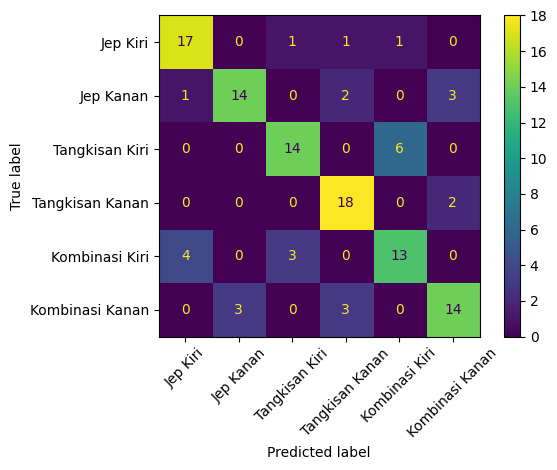

In [10]:
import joblib
import numpy as np
import pandas as pd
from datetime import datetime
from scipy import stats as scipy_stats
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Re-use the build_dataset function and all helpers from your pipeline file.
# If you prefer, you can import them directly:
# from silat_svm_pipeline import build_dataset, MOVEMENT_CLASSES
# But to keep it self-contained, I'm copying the essentials here.

# ---------- Minimal copy of your feature extraction & dataset builder ----------
N_SENSORS = 4
ACCEL_COLS = [[f"a{a}{i}" for a in "xyz"] for i in range(N_SENSORS)]
GYRO_COLS  = [[f"g{a}{i}" for a in "xyz"] for i in range(N_SENSORS)]
MOVEMENT_CLASSES = [
    "Jep Kiri", "Jep Kanan",
    "Tangkisan Kiri", "Tangkisan Kanan",
    "Kombinasi Kiri", "Kombinasi Kanan",
]

# (Same helper functions you have in the pipeline)
def parse_label_time(date_str, time_str):
    parts = time_str.split(",")
    hms = parts[0].replace(".", ":")
    ms = parts[1] if len(parts) > 1 else "0"
    return datetime.strptime(f"{date_str} {hms}.{ms}", "%Y-%m-%d %H:%M:%S.%f")

def load_subject_csv(subject_id):
    path = f"./data/subjek_{subject_id}.csv"   # adjust if needed
    return pd.read_csv(path, parse_dates=["timestamp"])

def _channel_stats(x):
    if len(x) == 0: return [0.0]*12
    mean=np.mean(x); std=np.std(x); xmin=np.min(x); xmax=np.max(x)
    rms=np.sqrt(np.mean(x**2)); rng=xmax-xmin; med=np.median(x)
    iqr=np.percentile(x,75)-np.percentile(x,25)
    skew=scipy_stats.skew(x) if len(x)>2 else 0.0
    kurt=scipy_stats.kurtosis(x) if len(x)>3 else 0.0
    fft_energy=np.sum(np.abs(np.fft.rfft(x))**2)/len(x)
    zcr=np.sum(np.abs(np.diff(np.sign(x-mean))))/(2*max(len(x)-1,1))
    return [mean,std,xmin,xmax,rms,rng,med,iqr,skew,kurt,fft_energy,zcr]

def _safe_corr(a,b):
    if len(a)<3: return 0.0
    sa,sb=np.std(a),np.std(b)
    if sa<1e-9 or sb<1e-9: return 0.0
    return np.corrcoef(a,b)[0,1]

def _accel_mag(data,cols,sensor_idx):
    idx=[cols.index(c) for c in ACCEL_COLS[sensor_idx] if c in cols]
    return np.sqrt(np.sum(data[:,idx]**2,axis=1)) if idx else np.zeros(len(data))

def _gyro_mag(data,cols,sensor_idx):
    idx=[cols.index(c) for c in GYRO_COLS[sensor_idx] if c in cols]
    return np.sqrt(np.sum(data[:,idx]**2,axis=1)) if idx else np.zeros(len(data))

def extract_features(segment):
    data = segment.drop(columns=["timestamp"]).values.astype(float)
    cols = [c for c in segment.columns if c != "timestamp"]
    n = len(data)
    EPS = 1e-9
    feats = []
    for i in range(data.shape[1]):
        feats.extend(_channel_stats(data[:,i]))
    s0_am = _accel_mag(data,cols,0); s1_am = _accel_mag(data,cols,1)
    s2_am = _accel_mag(data,cols,2); s3_am = _accel_mag(data,cols,3)
    s0_gm = _gyro_mag(data,cols,0); s1_gm = _gyro_mag(data,cols,1)
    s2_gm = _gyro_mag(data,cols,2); s3_gm = _gyro_mag(data,cols,3)
    for am,gm in [(s0_am,s0_gm),(s1_am,s1_gm),(s2_am,s2_gm),(s3_am,s3_gm)]:
        feats.extend(_channel_stats(am))
        feats.extend(_channel_stats(gm))
    right_am = (s0_am+s1_am)/2; left_am = (s2_am+s3_am)/2
    right_gm = (s0_gm+s1_gm)/2; left_gm = (s2_gm+s3_gm)/2
    feats.extend(_channel_stats(right_am-left_am))
    feats.extend(_channel_stats(right_gm-left_gm))
    r_palm_mean=np.mean(s0_am); r_fore_mean=np.mean(s1_am)
    l_palm_mean=np.mean(s3_am); l_fore_mean=np.mean(s2_am)
    r_palm_g_mean=np.mean(s0_gm); r_fore_g_mean=np.mean(s1_gm)
    l_palm_g_mean=np.mean(s3_gm); l_fore_g_mean=np.mean(s2_gm)
    feats.append(r_palm_mean/(r_palm_mean+r_fore_mean+EPS))
    feats.append(l_palm_mean/(l_palm_mean+l_fore_mean+EPS))
    feats.append(r_palm_g_mean/(r_palm_g_mean+r_fore_g_mean+EPS))
    feats.append(l_palm_g_mean/(l_palm_g_mean+l_fore_g_mean+EPS))
    feats.append(_safe_corr(s0_am,s1_am)); feats.append(_safe_corr(s3_am,s2_am))
    feats.append(_safe_corr(s0_gm,s1_gm)); feats.append(_safe_corr(s3_gm,s2_gm))
    r_peak=np.max(right_am); l_peak=np.max(left_am)
    r_g_peak=np.max(right_gm); l_g_peak=np.max(left_gm)
    feats.append(r_peak/(l_peak+EPS)); feats.append(r_g_peak/(l_g_peak+EPS))
    feats.append(np.argmax(s0_am)/max(n-1,1)); feats.append(np.argmax(s1_am)/max(n-1,1))
    feats.append(np.argmax(s3_am)/max(n-1,1)); feats.append(np.argmax(s2_am)/max(n-1,1))
    feats.append(np.mean(right_am**2)); feats.append(np.mean(left_am**2))
    feats.append(np.mean(right_gm**2)); feats.append(np.mean(left_gm**2))
    return np.array(feats, dtype=np.float64)

# The raw labels (you can copy the whole list from your code; here I'm only showing a few)
RAW_LABELS = [
    (1, "2026-04-30", "13.44.31,069", "13.44.34,855", "Jep Kiri",      "Benar"),
    (1, "2026-04-30", "13.45.01,092", "13.45.06,498", "Jep Kanan",     "Benar"),
    (1, "2026-04-30", "13.45.30,258", "13.45.35,273", "Jep Kiri",      "Salah"),
    (1, "2026-04-30", "13.45.49,611", "13.45.54,609", "Jep Kanan",     "Salah"),
    (1, "2026-04-30", "13.46.11,124", "13.46.22,535", "Tangkisan Kiri","Benar"),
    (1, "2026-04-30", "13.46.38,449", "13.46.44,622", "Tangkisan Kanan","Benar"),
    (1, "2026-04-30", "13.47.00,623", "13.47.07,020", "Tangkisan Kiri","Salah"),
    (1, "2026-04-30", "13.47.23,820", "13.47.29,843", "Tangkisan Kanan","Salah"),
    (1, "2026-04-30", "13.47.43,737", "13.47.49,320", "Kombinasi Kiri","Benar"),
    (1, "2026-04-30", "13.48.05,540", "13.48.12,940", "Kombinasi Kanan","Benar"),
    (1, "2026-04-30", "13.48.42,263", "13.48.51,273", "Kombinasi Kiri","Salah"),
    (1, "2026-04-30", "13.49.07,247", "13.49.12,302", "Kombinasi Kanan","Salah"),

    (2, "2026-05-01", "16.23.41,027", "16.23.45,452", "Jep Kiri",      "Benar"),
    (2, "2026-05-01", "16.23.56,789", "16.24.02,048", "Jep Kanan",     "Benar"),
    (2, "2026-05-01", "16.24.31,625", "16.24.36,441", "Jep Kiri",      "Salah"),
    (2, "2026-05-01", "16.24.47,194", "16.24.51,711", "Jep Kanan",     "Salah"),
    (2, "2026-05-01", "16.28.52,247", "16.28.59,003", "Tangkisan Kiri","Benar"),
    (2, "2026-05-01", "16.29.08,117", "16.29.16,609", "Tangkisan Kanan","Benar"),
    (2, "2026-05-01", "16.29.26,549", "16.29.32,581", "Tangkisan Kiri","Salah"),
    (2, "2026-05-01", "16.29.42,077", "16.29.50,066", "Tangkisan Kanan","Salah"),
    (2, "2026-05-01", "16.26.10,141", "16.26.17,245", "Kombinasi Kiri","Benar"),
    (2, "2026-05-01", "16.26.29,392", "16.26.36,560", "Kombinasi Kanan","Benar"),
    (2, "2026-05-01", "16.26.43,831", "16.26.49,992", "Kombinasi Kiri","Salah"),
    (2, "2026-05-01", "16.26.59,629", "16.27.05,926", "Kombinasi Kanan","Salah"),

    (3, "2026-05-01", "17.17.01,800", "17.17.07,302", "Jep Kiri",      "Benar"),
    (3, "2026-05-01", "17.17.17,006", "17.17.23,470", "Jep Kanan",     "Benar"),
    (3, "2026-05-01", "17.17.31,784", "17.17.37,817", "Jep Kiri",      "Salah"),
    (3, "2026-05-01", "17.17.46,703", "17.17.53,361", "Jep Kanan",     "Salah"),
    (3, "2026-05-01", "17.18.01,379", "17.18.06,774", "Tangkisan Kiri","Benar"),
    (3, "2026-05-01", "17.18.14,200", "17.18.20,906", "Tangkisan Kanan","Benar"),
    (3, "2026-05-01", "17.18.29,508", "17.18.35,206", "Tangkisan Kiri","Salah"),
    (3, "2026-05-01", "17.18.46,609", "17.18.54,494", "Tangkisan Kanan","Salah"),
    (3, "2026-05-01", "17.20.54,570", "17.21.02,393", "Kombinasi Kiri","Benar"),
    (3, "2026-05-01", "17.21.08,890", "17.21.19,599", "Kombinasi Kanan","Benar"),
    (3, "2026-05-01", "17.21.24,715", "17.21.33,603", "Kombinasi Kiri","Salah"),
    (3, "2026-05-01", "17.21.40,304", "17.21.53,802", "Kombinasi Kanan","Salah"),

    (4, "2026-05-01", "17.40.44,126", "17.40.52,303", "Jep Kiri",      "Benar"),
    (4, "2026-05-01", "17.41.02,836", "17.41.06,965", "Jep Kanan",     "Benar"),
    (4, "2026-05-01", "17.41.17,321", "17.41.22,429", "Jep Kiri",      "Salah"),
    (4, "2026-05-01", "17.41.33,279", "17.41.40,266", "Jep Kanan",     "Salah"),
    (4, "2026-05-01", "17.41.47,422", "17.41.51,507", "Tangkisan Kiri","Benar"),
    (4, "2026-05-01", "17.41.58,492", "17.42.05,126", "Tangkisan Kanan","Benar"),
    (4, "2026-05-01", "17.42.10,565", "17.42.17,099", "Tangkisan Kiri","Salah"),
    (4, "2026-05-01", "17.42.22,958", "17.42.37,121", "Tangkisan Kanan","Salah"),
    (4, "2026-05-01", "17.42.45,240", "17.42.51,754", "Kombinasi Kiri","Benar"),
    (4, "2026-05-01", "17.42.59,279", "17.43.04,863", "Kombinasi Kanan","Benar"),
    (4, "2026-05-01", "17.43.10,735", "17.43.15,272", "Kombinasi Kiri","Salah"),
    (4, "2026-05-01", "17.43.23,259", "17.43.28,482", "Kombinasi Kanan","Salah"),

    (5, "2026-05-01", "17.55.23,658", "17.55.28,074", "Jep Kiri",      "Benar"),
    (5, "2026-05-01", "17.55.34,240", "17.55.38,454", "Jep Kanan",     "Benar"),
    (5, "2026-05-01", "17.55.44,862", "17.55.48,484", "Jep Kiri",      "Salah"),
    (5, "2026-05-01", "17.55.57,664", "17.56.01,861", "Jep Kanan",     "Salah"),
    (5, "2026-05-01", "17.56.08,730", "17.56.12,854", "Tangkisan Kiri","Benar"),
    (5, "2026-05-01", "17.56.20,040", "17.56.24,082", "Tangkisan Kanan","Benar"),
    (5, "2026-05-01", "17.56.31,174", "17.56.34,557", "Tangkisan Kiri","Salah"),
    (5, "2026-05-01", "17.56.42,756", "17.56.46,098", "Tangkisan Kanan","Salah"),
    (5, "2026-05-01", "17.56.53,266", "17.56.59,946", "Kombinasi Kiri","Benar"),
    (5, "2026-05-01", "17.57.08,442", "17.57.12,659", "Kombinasi Kanan","Benar"),
    (5, "2026-05-01", "17.57.18,764", "17.57.24,841", "Kombinasi Kiri","Salah"),
    (5, "2026-05-01", "17.57.30,969", "17.57.36,757", "Kombinasi Kanan","Salah"),

    (6, "2026-05-01", "18.05.15,534", "18.05.22,778", "Jep Kiri",      "Benar"),
    (6, "2026-05-01", "18.05.38,271", "18.05.45,147", "Jep Kanan",     "Benar"),
    (6, "2026-05-01", "18.05.53,545", "18.06.01,449", "Jep Kiri",      "Salah"),
    (6, "2026-05-01", "18.06.08,004", "18.06.14,063", "Jep Kanan",     "Salah"),
    (6, "2026-05-01", "18.06.24,099", "18.06.33,175", "Tangkisan Kiri","Benar"),
    (6, "2026-05-01", "18.06.44,029", "18.06.49,154", "Tangkisan Kanan","Benar"),
    (6, "2026-05-01", "18.06.57,116", "18.07.02,635", "Tangkisan Kiri","Salah"),
    (6, "2026-05-01", "18.07.11,948", "18.07.17,633", "Tangkisan Kanan","Salah"),
    (6, "2026-05-01", "18.07.32,450", "18.07.41,335", "Kombinasi Kiri","Benar"),
    (6, "2026-05-01", "18.07.48,953", "18.07.56,540", "Kombinasi Kanan","Benar"),
    (6, "2026-05-01", "18.08.03,204", "18.08.11,994", "Kombinasi Kiri","Salah"),
    (6, "2026-05-01", "18.08.26,568", "18.08.32,101", "Kombinasi Kanan","Salah"),

    (7, "2026-05-02", "21.49.26,693", "21.49.31,790", "Jep Kiri",      "Benar"),
    (7, "2026-05-02", "21.49.38,295", "21.49.42,976", "Jep Kanan",     "Benar"),
    (7, "2026-05-02", "21.49.49,660", "21.49.56,696", "Jep Kiri",      "Salah"),
    (7, "2026-05-02", "21.50.04,080", "21.50.10,916", "Jep Kanan",     "Salah"),
    (7, "2026-05-02", "21.50.18,605", "21.50.30,416", "Tangkisan Kiri","Benar"),
    (7, "2026-05-02", "21.50.39,496", "21.50.46,113", "Tangkisan Kanan","Benar"),
    (7, "2026-05-02", "21.50.53,422", "21.51.00,489", "Tangkisan Kiri","Salah"),
    (7, "2026-05-02", "21.51.07,530", "21.51.13,289", "Tangkisan Kanan","Salah"),
    (7, "2026-05-02", "21.51.20,412", "21.51.28,237", "Kombinasi Kiri","Benar"),
    (7, "2026-05-02", "21.51.36,222", "21.51.43,909", "Kombinasi Kanan","Benar"),
    (7, "2026-05-02", "21.51.50,661", "21.51.57,010", "Kombinasi Kiri","Salah"),
    (7, "2026-05-02", "21.52.06,006", "21.52.13,288", "Kombinasi Kanan","Salah"),
    (8, "2026-05-02", "21.31.30,657", "21.31.40,672", "Jep Kiri",      "Benar"),
    (8, "2026-05-02", "21.32.02,138", "21.32.12,127", "Jep Kanan",     "Benar"),
    (8, "2026-05-02", "21.32.23,081", "21.32.33,231", "Jep Kiri",      "Salah"),
    (8, "2026-05-02", "21.32.39,499", "21.32.45,529", "Jep Kanan",     "Salah"),
    (8, "2026-05-02", "21.32.57,288", "21.33.04,000", "Tangkisan Kiri","Benar"),
    (8, "2026-05-02", "21.33.22,583", "21.33.28,201", "Tangkisan Kanan","Benar"),
    (8, "2026-05-02", "21.33.38,662", "21.33.48,371", "Tangkisan Kiri","Salah"),
    (8, "2026-05-02", "21.34.02,712", "21.34.15,372", "Tangkisan Kanan","Salah"),
    (8, "2026-05-02", "21.34.29,429", "21.34.38,132", "Kombinasi Kiri","Benar"),
    (8, "2026-05-02", "21.34.46,735", "21.34.57,594", "Kombinasi Kanan","Benar"),
    (8, "2026-05-02", "21.35.09,191", "21.35.16,119", "Kombinasi Kiri","Salah"),
    (8, "2026-05-02", "21.35.22,388", "21.35.31,207", "Kombinasi Kanan","Salah"),
    (9, "2026-05-02", "22.02.53,580", "22.02.58,278", "Jep Kiri",      "Benar"),
    (9, "2026-05-02", "22.03.04,114", "22.03.08,005", "Jep Kanan",     "Benar"),
    (9, "2026-05-02", "22.03.14,465", "22.03.18,040", "Jep Kiri",      "Salah"),
    (9, "2026-05-02", "22.03.23,270", "22.03.30,951", "Jep Kanan",     "Salah"),
    (9, "2026-05-02", "22.03.39,948", "22.03.46,507", "Tangkisan Kiri","Benar"),
    (9, "2026-05-02", "22.03.50,295", "22.03.58,488", "Tangkisan Kanan","Benar"),
    (9, "2026-05-02", "22.04.09,403", "22.04.14,214", "Tangkisan Kiri","Salah"),
    (9, "2026-05-02", "22.04.23,530", "22.04.38,718", "Tangkisan Kanan","Salah"),
    (9, "2026-05-02", "22.04.45,293", "22.04.50,707", "Kombinasi Kiri","Benar"),
    (9, "2026-05-02", "22.04.55,854", "22.05.00,744", "Kombinasi Kanan","Benar"),
    (9, "2026-05-02", "22.05.09,483", "22.05.15,591", "Kombinasi Kiri","Salah"),
    (9, "2026-05-02", "22.05.25,320", "22.05.30,747", "Kombinasi Kanan","Salah"),
    (10, "2026-05-02", "22.15.50,249", "22.15.56,071", "Jep Kiri",      "Benar"),
    (10, "2026-05-02", "22.16.00,592", "22.16.09,259", "Jep Kanan",     "Benar"),
    (10, "2026-05-02", "22.16.14,617", "22.16.21,068", "Jep Kiri",      "Salah"),
    (10, "2026-05-02", "22.16.40,145", "22.16.43,810", "Jep Kanan",     "Salah"),
    (10, "2026-05-02", "22.16.53,239", "22.16.57,118", "Tangkisan Kiri","Benar"),
    (10, "2026-05-02", "22.17.05,309", "22.17.11,243", "Tangkisan Kanan","Benar"),
    (10, "2026-05-02", "22.18.05,617", "22.18.13,809", "Tangkisan Kiri","Salah"),
    (10, "2026-05-02", "22.18.19,135", "22.18.27,415", "Tangkisan Kanan","Salah"),
    (10, "2026-05-02", "22.18.34,493", "22.18.44,733", "Kombinasi Kiri","Benar"),
    (10, "2026-05-02", "22.18.51,212", "22.19.00,115", "Kombinasi Kanan","Benar"),
    (10, "2026-05-02", "22.19.12,380", "22.19.18,525", "Kombinasi Kiri","Salah"),
    (10, "2026-05-02", "22.19.24,399", "22.19.34,293", "Kombinasi Kanan","Salah"),
]

# If you have the full list already in a variable, just assign RAW_LABELS = your_existing_variable

def build_dataset():
    label_df = pd.DataFrame(RAW_LABELS, columns=["subject","date","t_start","t_end","movement","correctness"])
    cache={}; X_mv,y_mv,subj=[],[],[]
    per_class={mv:{"X":[],"y":[],"subjects":[]} for mv in MOVEMENT_CLASSES}
    skipped=0
    for _,row in label_df.iterrows():
        sid=int(row["subject"])
        if sid not in cache:
            try: cache[sid]=load_subject_csv(sid)
            except FileNotFoundError as e: print(f"  [WARN] {e}"); skipped+=1; continue
        df=cache[sid]
        t_start=parse_label_time(row["date"],row["t_start"])
        t_end=parse_label_time(row["date"],row["t_end"])
        seg=df[(df["timestamp"]>=t_start)&(df["timestamp"]<=t_end)]
        if len(seg)<3: print(f"  [WARN] {len(seg)} rows subj {sid}"); skipped+=1; continue
        feat=extract_features(seg)
        mv=row["movement"]; corr=1 if row["correctness"]=="Benar" else 0
        X_mv.append(feat); y_mv.append(mv); subj.append(sid)
        per_class[mv]["X"].append(feat); per_class[mv]["y"].append(corr)
        per_class[mv]["subjects"].append(sid)
    X_mv=np.array(X_mv); y_mv=np.array(y_mv); subj=np.array(subj)
    for mv in MOVEMENT_CLASSES:
        per_class[mv]["X"]=np.array(per_class[mv]["X"])
        per_class[mv]["y"]=np.array(per_class[mv]["y"])
        per_class[mv]["subjects"]=np.array(per_class[mv]["subjects"])
    return X_mv, y_mv, subj, per_class

print("Building dataset...")
X_mv, y_mv, subj, per_class = build_dataset()
print(f"Loaded {len(X_mv)} samples.")

# Now the confusion matrix
model = joblib.load("models/model_movement.pkl")
y_pred = model.predict(X_mv)
cm = confusion_matrix(y_mv, y_pred, labels=MOVEMENT_CLASSES)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=MOVEMENT_CLASSES)
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()